## 전처리 수정 + EDA

In [87]:
from pathlib import Path

DATA_PATH = Path("/Users/kyoungchan/skn29/python/datasets/youtube_trends_KR.parquet")
# df = pd.read_parquet(DATA_PATH)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
df = pd.read_parquet(r"C:\Users\Playdata\Desktop\SKN29-2nd-1Team\data\raw\youtube_trends_KR.parquet")

In [88]:
print(df.head())
print(df.dtypes)

       collection_date region_code  rank     video_id  \
0  2022-07-01 00:00:00          KR     1  k1mccn55MyA   
1  2022-07-01 00:00:00          KR     2  tz5ZHaa-qwA   
2  2022-07-01 00:00:00          KR     3  cfzpznYQ-Tg   
3  2022-07-01 00:00:00          KR     4  YlNe0TbblXY   
4  2022-07-01 00:00:00          KR     5  vJvX9L6FCWI   

                                               title  \
0  [ENG][차이나는 밤샘토크] 술? 못해요🤣 장꾸미 폭발한 손석구와 함께한 '나의 ...   
1  2022 임영웅 전국투어 콘서트 ‘IM HERO’ Tour Spot (Live Ver.)   
2               [찬또야 어디가? 1화]  첫 힐링 여행지 양평에 찬또가 떴다?🌞   
3              한국에서 맛보는 세계 - 중동 음식 with 알파고 시나씨, 공혁준   
4      선미 (SUNMI) - '열이올라요 (Heart Burn)' Music Video   

                                         description             published_at  \
0  💡 배우｜손석구드라마에선 주당인 줄 알았는데..🍺실제로는 술을 잘 안 먹는다고?!반...  2022-06-29 13:00:09.000   
1  #임영웅 #LimYoungWoong임영웅 웅튜브 구독♡좋아요♡알람설정열심히 할게요/...  2022-06-29 04:00:31.000   
2  찬또야 어디가? 첫 여행지로 선택된 경기도 양평🚗첫 목적지는 찬또가 선택한 양평오일...  2022-06-30 16:00:31.000

In [89]:
print(df.shape)
df.info

(872191, 15)


<bound method DataFrame.info of             collection_date region_code  rank     video_id  \
0       2022-07-01 00:00:00          KR     1  k1mccn55MyA   
1       2022-07-01 00:00:00          KR     2  tz5ZHaa-qwA   
2       2022-07-01 00:00:00          KR     3  cfzpznYQ-Tg   
3       2022-07-01 00:00:00          KR     4  YlNe0TbblXY   
4       2022-07-01 00:00:00          KR     5  vJvX9L6FCWI   
...                     ...         ...   ...          ...   
872186  2025-06-30 18:00:00          KR   196  8yliKIyKNSE   
872187  2025-06-30 18:00:00          KR   197  IoRfKxDxn58   
872188  2025-06-30 18:00:00          KR   198  RZUJhDgK5sM   
872189  2025-06-30 18:00:00          KR   199  Tbf9ZEnb6us   
872190  2025-06-30 18:00:00          KR   200  vQ97f_b2CpE   

                                                    title  \
0       [ENG][차이나는 밤샘토크] 술? 못해요🤣 장꾸미 폭발한 손석구와 함께한 '나의 ...   
1       2022 임영웅 전국투어 콘서트 ‘IM HERO’ Tour Spot (Live Ver.)   
2                    [찬또야 어디가? 1화]  첫 힐링

In [90]:
# step1. 데이터 무결성 확인 + KR 트렌딩 데이터 기본 정제

import pandas as pd
import numpy as np

df = df.copy()

# 0. 문자열 컬럼 결측 보정
df['title'] = df['title'].fillna('')
df['channel_title'] = df['channel_title'].fillna('')

# 1. datetime 변환 
# UTC 기준 timestamp를 한국시간(KST, UTC+9)으로 변환
df['collection_date'] = (
    pd.to_datetime(df['collection_date'], utc=True, errors='coerce')
    .dt.tz_convert('Asia/Seoul')
    .dt.tz_localize(None)
)

df['published_at'] = (
    pd.to_datetime(df['published_at'], utc=True, errors='coerce')
    .dt.tz_convert('Asia/Seoul')
    .dt.tz_localize(None)
)

# 2. 숫자형 변환
num_cols = ['view_count', 'comment_count', 'rank', 'category_id']

for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. 필수값 결측 제거
df = df.dropna(subset=[
    'video_id', 'channel_id', 'collection_date',
    'published_at', 'category_id', 'view_count', 'rank'
])
print("결측 제거 후:", df.shape)

# 4. 비정상 수치 제거
df = df[df['view_count'] > 0]
df = df[df['rank'].between(1, 200)]
print("비정상 수치 제거 후:", df.shape)

# 5. 중복 제거
# 같은 영상-같은 수집시점이 중복되면 rank가 가장 좋은 행,
# rank가 같으면 view_count가 큰 행을 유지
df = (
    df.sort_values(
        ['video_id', 'collection_date', 'rank', 'view_count'],
        ascending=[True, True, True, False]
    )
    .drop_duplicates(subset=['video_id', 'collection_date'], keep='first')
)
print("중복 제거 후:", df.shape)

# 6. KR 트렌딩 데이터 확인
# 이미 region_code == 'KR'만 추출한 데이터이므로
# 한국어 제목/채널명/default_language 기준으로 추가 필터링하지 않음
if 'region_code' in df.columns:
    print("\n[region_code 분포]")
    print(df['region_code'].value_counts(dropna=False))

# 7. 한국어 메타데이터 여부: 필터링용이 아니라 검사용
if 'default_language' in df.columns:
    df['has_korean_metadata'] = (
        df['title'].astype(str).str.contains(r'[가-힣]', na=False) |
        df['channel_title'].astype(str).str.contains(r'[가-힣]', na=False) |
        (df['default_language'].fillna('') == 'ko')
    ).astype(int)
else:
    df['has_korean_metadata'] = (
        df['title'].astype(str).str.contains(r'[가-힣]', na=False) |
        df['channel_title'].astype(str).str.contains(r'[가-힣]', na=False)
    ).astype(int)

print("\n[한국어 메타데이터 여부]")
print(df['has_korean_metadata'].value_counts(dropna=False))

# 8. comment_count 결측 → 0
df['comment_count_missing'] = df['comment_count'].isna().astype(int)
df['comment_count'] = df['comment_count'].fillna(0)

# comment_count 음수 제거
df = df[df['comment_count'] >= 0]
print("comment_count 처리 후:", df.shape)

# 9. 불필요 컬럼 제거
# default_language, region_code는 아직 검증용으로 남겨두는 것을 추천
drop_cols = [
    'description',
    'default_audio_language',
    'live_broadcast_content'
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])

print("\n최종:", df.shape)
print(df.isnull().sum().sort_values(ascending=False))

결측 제거 후: (872191, 15)
비정상 수치 제거 후: (872191, 15)
중복 제거 후: (872191, 15)

[region_code 분포]
region_code
KR    872191
Name: count, dtype: Int64

[한국어 메타데이터 여부]
has_korean_metadata
1    820630
0     51561
Name: count, dtype: int64
comment_count 처리 후: (872191, 17)

최종: (872191, 14)
default_language         555185
collection_date               0
region_code                   0
rank                          0
video_id                      0
title                         0
published_at                  0
channel_id                    0
channel_title                 0
category_id                   0
view_count                    0
comment_count                 0
has_korean_metadata           0
comment_count_missing         0
dtype: int64


In [91]:
# =========================
# Step 2. 카테고리 정규화 (5그룹)
# =========================

# 목적:
# - YouTube 원본 category_id를 해석 가능한 상위 그룹으로 재분류
# - 단, 클러스터 K=4는 트렌딩 패턴 유형화용이므로 여기서 category_group과 섞지 않음
# - category_group은 RQ1, RQ2, RQ3의 설명 변수로 사용

# 1. category_id 정수형 변환
# Step 1에서 결측 제거가 끝난 뒤 실행해야 함
df['category_id'] = df['category_id'].astype(int)

# 2. 카테고리 그룹 매핑
category_map = {
    # Entertainment-like
    24: 'Entertainment',  # Entertainment
    17: 'Entertainment',  # Sports
    20: 'Entertainment',  # Gaming
    1:  'Entertainment',  # Film & Animation
    23: 'Entertainment',  # Comedy

    # Music
    10: 'Music',

    # Lifestyle
    19: 'Lifestyle',      # Travel & Events
    15: 'Lifestyle',      # Pets & Animals
    2:  'Lifestyle',      # Autos & Vehicles
    22: 'Lifestyle',      # People & Blogs
    26: 'Lifestyle',      # Howto & Style

    # Education / Information
    27: 'Education',      # Education
    28: 'Education',      # Science & Technology

    # News / Public issues
    25: 'News',           # News & Politics
    29: 'News',           # Nonprofits & Activism
}

category_name_map = {
    1: 'Film&Animation',
    2: 'Autos',
    10: 'Music',
    15: 'Pets',
    17: 'Sports',
    19: 'Travel',
    20: 'Gaming',
    22: 'People&Blogs',
    23: 'Comedy',
    24: 'Entertainment',
    25: 'News',
    26: 'Howto&Style',
    27: 'Education',
    28: 'SciTech',
    29: 'Nonprofits',
    30: 'Movies',
    43: 'Shows'
}

df['category_name'] = df['category_id'].map(category_name_map).fillna('Other')
df['category_group'] = df['category_id'].map(category_map).fillna('Other')

# 3. 원본 category_id 분포 확인
print("[category_id 분포]")
print(df['category_id'].value_counts(dropna=False).sort_index())

# 4. 재분류된 category_group 분포 확인
print("\n[category_group 분포: row 기준]")
print(df['category_group'].value_counts(dropna=False))

print("\n[category_group 비율: row 기준]")
print(df['category_group'].value_counts(normalize=True, dropna=False).round(4))

# 5. Other 확인
# Other가 많으면 category_map에서 빠진 category_id가 있다는 뜻
print("\n[Other에 포함된 category_id]")
print(df.loc[df['category_group'] == 'Other', 'category_id'].value_counts(dropna=False))

# 6. 스냅샷 단위 기준 요약
# 현재 df는 아직 이벤트 단위가 아니라 수집 시점별 snapshot 단위임
# 따라서 n_rows는 영상 수가 아니라 관측 행 수임
cat_summary = (
    df.groupby('category_group')
      .agg(
          n_rows=('video_id', 'size'),
          n_videos=('video_id', 'nunique'),
          n_channels=('channel_id', 'nunique')
      )
      .sort_values('n_rows', ascending=False)
)

cat_summary['row_ratio'] = (cat_summary['n_rows'] / len(df)).round(4)
cat_summary['video_ratio'] = (cat_summary['n_videos'] / df['video_id'].nunique()).round(4)

print("\n[category_group 요약: snapshot 기준]")
display(cat_summary)

# 7. 세부 category_id가 category_group 안에서 어떻게 묶였는지 확인
category_detail = (
    df.groupby(['category_group', 'category_id'])
      .agg(
          n_rows=('video_id', 'size'),
          n_videos=('video_id', 'nunique'),
          n_channels=('channel_id', 'nunique')
      )
      .sort_values(['category_group', 'n_videos'], ascending=[True, False])
)

category_detail['row_ratio_total'] = (category_detail['n_rows'] / len(df)).round(4)
category_detail['video_ratio_total'] = (category_detail['n_videos'] / df['video_id'].nunique()).round(4)

print("\n[category_group 내부 세부 category_id 분포]")
display(category_detail)

[category_id 분포]
category_id
1      17491
2       2021
10    107410
15     14619
17     57967
19     33762
20     39995
22    185656
23     59311
24    283753
25     15135
26     34848
27      7878
28      9973
29      2372
Name: count, dtype: int64

[category_group 분포: row 기준]
category_group
Entertainment    458517
Lifestyle        270906
Music            107410
Education         17851
News              17507
Name: count, dtype: int64

[category_group 비율: row 기준]
category_group
Entertainment    0.5257
Lifestyle        0.3106
Music            0.1231
Education        0.0205
News             0.0201
Name: proportion, dtype: float64

[Other에 포함된 category_id]
Series([], Name: count, dtype: int64)

[category_group 요약: snapshot 기준]


,n_rows,n_videos,n_channels,row_ratio,video_ratio
category_group,,,,,
Entertainment,458517,9718,1081,0.5257,0.5434
Lifestyle,270906,5134,827,0.3106,0.2871
Music,107410,2233,386,0.1231,0.1249
Education,17851,364,85,0.0205,0.0204
News,17507,459,70,0.0201,0.0257



[category_group 내부 세부 category_id 분포]


n_rows  n_videos  n_channels  row_ratio_total  \
category_group category_id                                                  
Education      28             9973       198          39           0.0114   
               27             7878       166          47           0.0090   
Entertainment  24           283753      5948         653           0.3253   
               17            57967      1503         176           0.0665   
               23            59311      1027          74           0.0680   
               20            39995       904         164           0.0459   
               1             17491       344          53           0.0201   
Lifestyle      22           185656      3525         566           0.2129   
               26            34848       645         115           0.0400   
               19            33762       618          97           0.0387   
               15            14619       304          59           0.0168   
               2              2021        43          18           0.0023   
Music          10           107410      2233         386           0.1231   
News           25            15135       413          66           0.0174   
               29             2372        46           4           0.0027   

                            video_ratio_total  
category_group category_id                     
Education      28                      0.0111  
               27                      0.0093  
Entertainment  24                      0.3326  
               17                      0.0840  
               23                      0.0574  
               20                      0.0505  
               1                       0.0192  
Lifestyle      22                      0.1971  
               26                      0.0361  
               19                      0.0346  
               15                      0.0170  
               2                       0.0024  
Music          10                      0.1249  
News           25                      0.0231  
               29                      0.0026

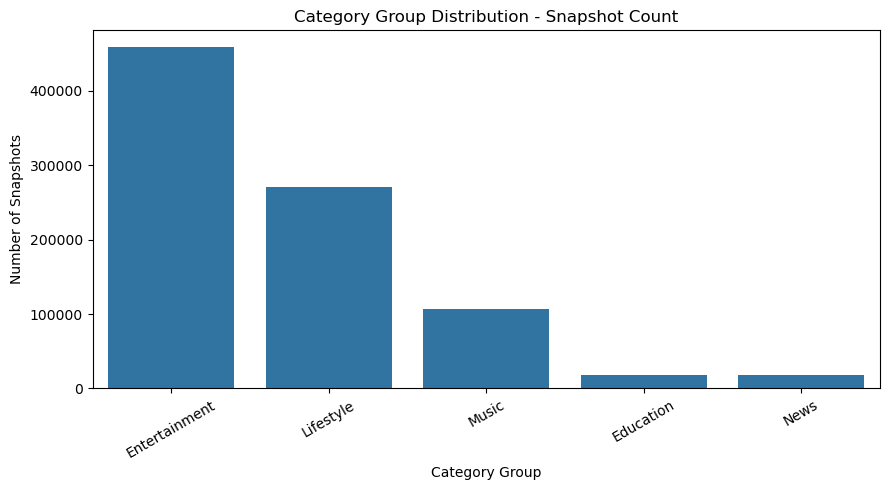

In [92]:
plt.figure(figsize=(9, 5))

order = df['category_group'].value_counts().index

sns.countplot(
    data=df,
    x='category_group',
    order=order
)

plt.title('Category Group Distribution - Snapshot Count')
plt.xlabel('Category Group')
plt.ylabel('Number of Snapshots')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

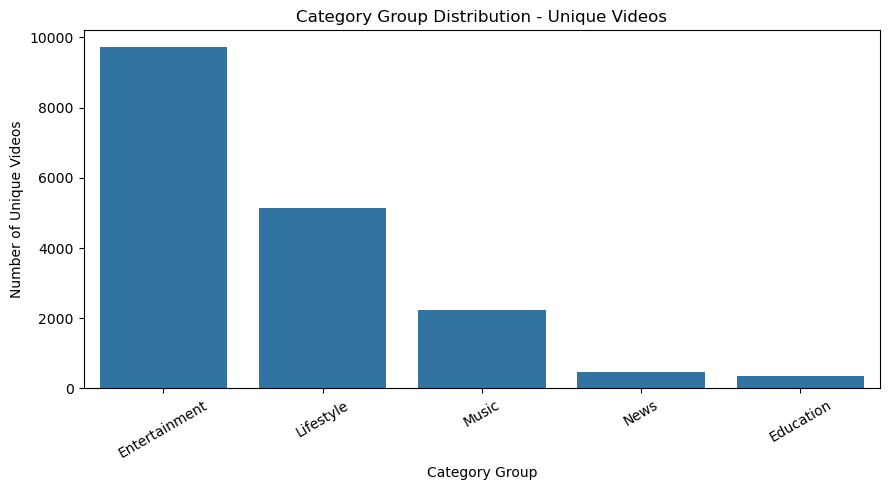

In [93]:
video_count_by_group = (
    df.groupby('category_group')['video_id']
      .nunique()
      .sort_values(ascending=False)
      .reset_index(name='n_videos')
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=video_count_by_group,
    x='category_group',
    y='n_videos',
    order=video_count_by_group['category_group']
)

plt.title('Category Group Distribution - Unique Videos')
plt.xlabel('Category Group')
plt.ylabel('Number of Unique Videos')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

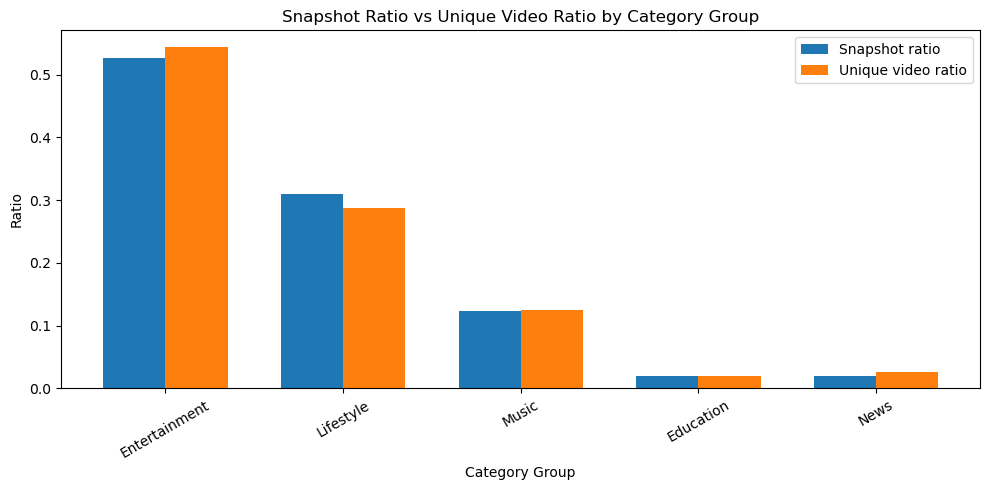

In [94]:
cat_summary_plot = cat_summary.reset_index()

plt.figure(figsize=(10, 5))

x = range(len(cat_summary_plot))
width = 0.35

plt.bar(
    [i - width/2 for i in x],
    cat_summary_plot['row_ratio'],
    width=width,
    label='Snapshot ratio'
)

plt.bar(
    [i + width/2 for i in x],
    cat_summary_plot['video_ratio'],
    width=width,
    label='Unique video ratio'
)

plt.xticks(x, cat_summary_plot['category_group'], rotation=30)
plt.title('Snapshot Ratio vs Unique Video Ratio by Category Group')
plt.xlabel('Category Group')
plt.ylabel('Ratio')
plt.legend()
plt.tight_layout()
plt.show()

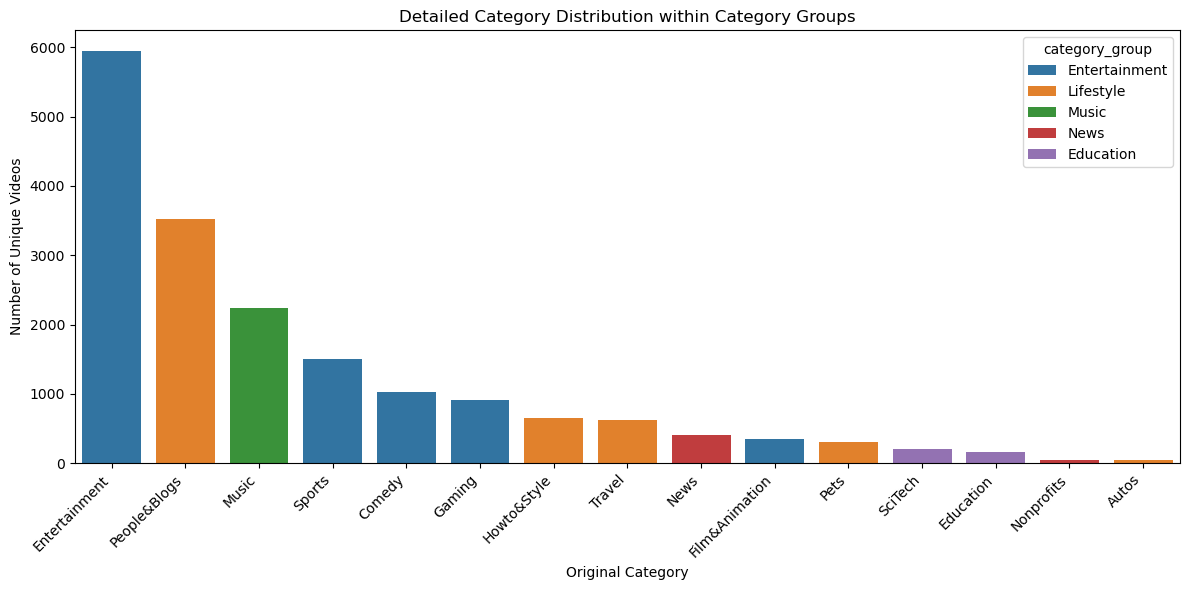

In [95]:
detail_plot = (
    df.groupby(['category_group', 'category_name'])['video_id']
      .nunique()
      .reset_index(name='n_videos')
      .sort_values('n_videos', ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=detail_plot,
    x='category_name',
    y='n_videos',
    hue='category_group'
)


plt.title('Detailed Category Distribution within Category Groups')
plt.xlabel('Original Category')
plt.ylabel('Number of Unique Videos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

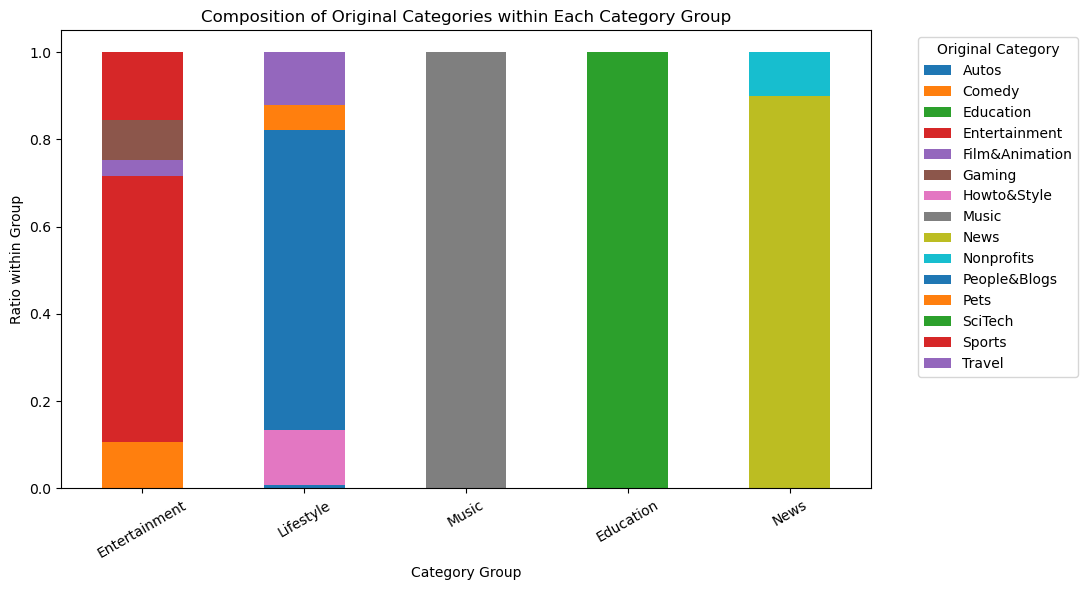

In [96]:
group_detail_ratio = (
    df.groupby(['category_group', 'category_name'])['video_id']
      .nunique()
      .reset_index(name='n_videos')
)

group_detail_ratio['group_total'] = (
    group_detail_ratio.groupby('category_group')['n_videos']
    .transform('sum')
)

group_detail_ratio['ratio'] = (
    group_detail_ratio['n_videos'] / group_detail_ratio['group_total']
)

pivot_ratio = group_detail_ratio.pivot(
    index='category_group',
    columns='category_name',
    values='ratio'
).fillna(0)

pivot_ratio = pivot_ratio.loc[cat_summary.index]

pivot_ratio.plot(
    kind='bar',
    stacked=True,
    figsize=(11, 6)
)

plt.title('Composition of Original Categories within Each Category Group')
plt.xlabel('Category Group')
plt.ylabel('Ratio within Group')
plt.xticks(rotation=30)
plt.legend(title='Original Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##################################################

In [97]:
# =========================
# Step 3. 재진입 이벤트 분리
# =========================

# 목적:
# - 동일 video_id가 트렌딩 차트에서 빠졌다가 다시 등장할 수 있으므로
#   6시간 초과 공백을 기준으로 별도 트렌딩 이벤트로 분리
# - event_id는 video_id 내부에서만 의미가 있으므로,
#   이후 이벤트 고유 키는 반드시 ['video_id', 'event_id']를 사용

df = df.sort_values(['video_id', 'collection_date']).copy()

# 1. 스냅샷 간 시간 간격 계산
df['time_gap_h'] = (
    df.groupby('video_id')['collection_date']
      .diff()
      .dt.total_seconds() / 3600
).round(3)

# 2. 새 이벤트 여부
# 첫 관측치 또는 6시간 초과 공백이면 새 이벤트로 정의
df['new_event'] = (df['time_gap_h'].isna()) | (df['time_gap_h'] > 6)

# 3. video_id별 event_id 생성
df['event_id'] = df.groupby('video_id')['new_event'].cumsum().astype(int)

# 4. 기본 확인
print("[Step 3 완료]")
print("전체 행 수:", df.shape[0])
print("고유 video 수:", df['video_id'].nunique())
print("고유 event 수:", df.groupby(['video_id', 'event_id']).ngroups)

print("\n[time_gap_h 요약]")
print(df['time_gap_h'].describe())

print("\n[time_gap_h 주요 값]")
print(df['time_gap_h'].value_counts().sort_index().head(30))

print("\n[6시간 초과 공백 수]")
print((df['time_gap_h'] > 6).sum())

# 5. video_id별 이벤트 수 분포
event_counts = df.groupby('video_id')['event_id'].max()

print("\n[video_id별 이벤트 수 분포]")
print(event_counts.value_counts().sort_index())

# 6. 이벤트별 스냅샷 수 분포
event_size = (
    df.groupby(['video_id', 'event_id'])
      .size()
      .reset_index(name='n_snapshots')
)

print("\n[이벤트별 스냅샷 수 요약]")
print(event_size['n_snapshots'].describe())

print("\n[n_snapshots 분포]")
print(event_size['n_snapshots'].value_counts().sort_index().head(30))

# 7. 샘플 확인
display(
    df[['video_id', 'collection_date', 'time_gap_h', 'new_event', 'event_id']]
      .head(20)
)

[Step 3 완료]
전체 행 수: 872191
고유 video 수: 17884
고유 event 수: 34964

[time_gap_h 요약]
count    854307.000000
mean          6.771671
std           7.185688
min           6.000000
25%           6.000000
50%           6.000000
75%           6.000000
max         420.000000
Name: time_gap_h, dtype: float64

[time_gap_h 주요 값]
time_gap_h
6.0      837227
12.0       4399
18.0       1588
24.0       1047
30.0       1160
36.0        957
42.0        553
48.0        726
54.0       1388
60.0        860
66.0        412
72.0        604
78.0       1009
84.0        530
90.0        235
96.0        280
102.0       452
108.0       223
114.0       129
120.0       111
126.0       144
132.0        59
138.0        41
144.0        35
150.0        31
156.0        31
162.0         8
168.0        16
174.0         8
180.0        10
Name: count, dtype: int64

[6시간 초과 공백 수]
17080

[video_id별 이벤트 수 분포]
event_id
1    5786
2    8225
3    2994
4     696
5     149
6      23
7      10
9       1
Name: count, dtype: int64

[이벤트별 스냅

,video_id,collection_date,time_gap_h,new_event,event_id
395024,--24T6TzQvc,2023-11-11 15:00:00,NaN,True,1
395223,--24T6TzQvc,2023-11-11 21:00:00,6.0,False,1
396458,--24T6TzQvc,2023-11-13 09:00:00,36.0,True,2
396675,--24T6TzQvc,2023-11-13 15:00:00,6.0,False,2
396877,--24T6TzQvc,2023-11-13 21:00:00,6.0,False,2
397077,--24T6TzQvc,2023-11-14 03:00:00,6.0,False,2
397277,--24T6TzQvc,2023-11-14 09:00:00,6.0,False,2
397485,--24T6TzQvc,2023-11-14 15:00:00,6.0,False,2
397690,--24T6TzQvc,2023-11-14 21:00:00,6.0,False,2
397888,--24T6TzQvc,2023-11-15 03:00:00,6.0,False,2


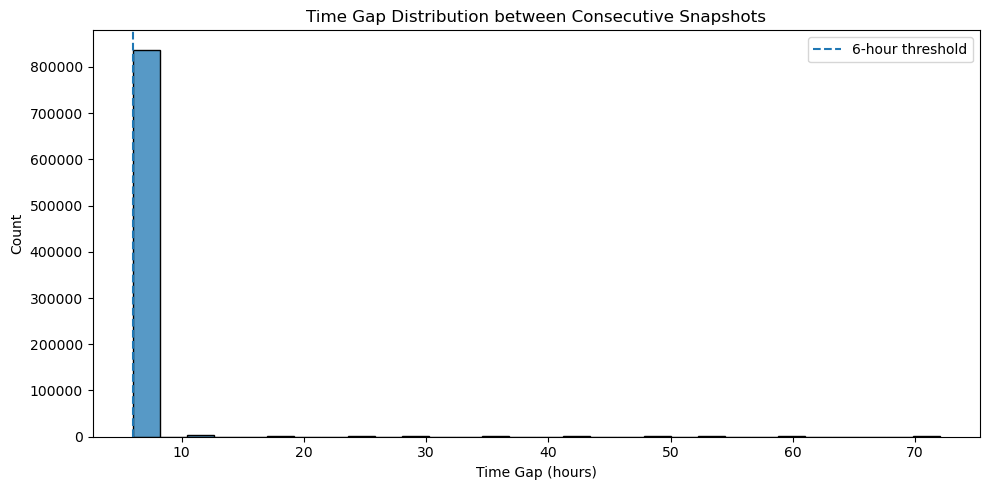

In [98]:
gap_data = df['time_gap_h'].dropna()

plt.figure(figsize=(10, 5))
sns.histplot(gap_data[gap_data <= 72], bins=30)
plt.axvline(6, linestyle='--', label='6-hour threshold')
plt.title('Time Gap Distribution between Consecutive Snapshots')
plt.xlabel('Time Gap (hours)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

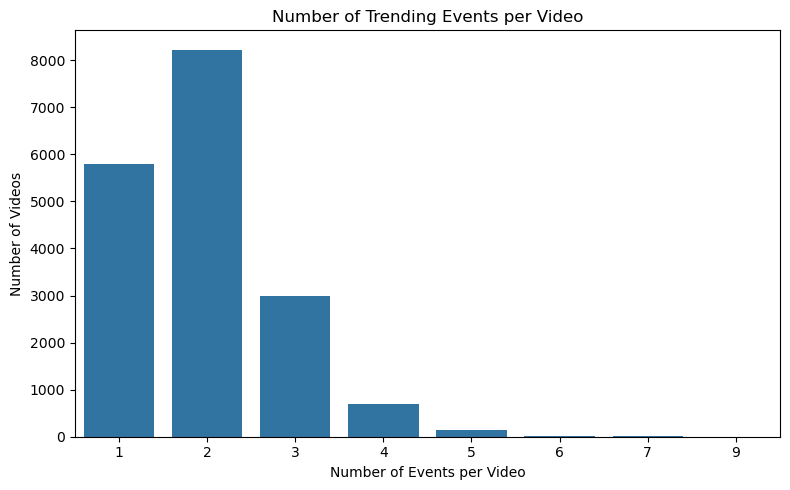

In [99]:
event_counts = df.groupby('video_id')['event_id'].max()

plt.figure(figsize=(8, 5))
sns.countplot(x=event_counts)
plt.title('Number of Trending Events per Video')
plt.xlabel('Number of Events per Video')
plt.ylabel('Number of Videos')
plt.tight_layout()
plt.show()

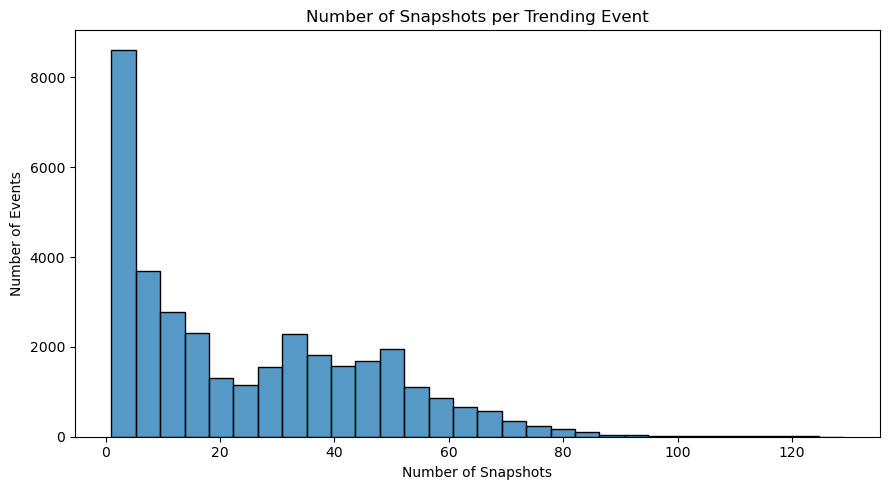

In [100]:
event_size = (
    df.groupby(['video_id', 'event_id'])
      .size()
      .reset_index(name='n_snapshots')
)

plt.figure(figsize=(9, 5))
sns.histplot(event_size['n_snapshots'], bins=30)
plt.title('Number of Snapshots per Trending Event')
plt.xlabel('Number of Snapshots')
plt.ylabel('Number of Events')
plt.tight_layout()
plt.show()

In [101]:
# =========================
# Step 4. view_growth_24h 생성 + EDA + 시각화
# =========================

# 목적:
# - 트렌딩 진입 후 정확히 24시간 동안의 조회수 증가량을 계산
# - view_growth_24h는 진입 후 24시간이 지난 시점에서만 알 수 있는 변수
# - 따라서 전체 T0 예측 모델에는 사용하지 않고,
#   has_24h_observation == True인 이벤트만 대상으로 하는 24h 모델에서만 사용
#
# 주의:
# - view_growth_24h를 전체 이벤트에 강제로 채우면 데이터 누수 위험이 있음
# - has_24h_observation도 예측 피처로 사용하면 안 됨
# - has_24h_observation은 24h 모델을 만들 때 필터링 조건으로만 사용

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 이벤트 고유키
event_key = ['video_id', 'event_id']

# 정렬
df = df.sort_values(event_key + ['collection_date']).copy()

# ---------------------------------------------------------
# 1. 이벤트별 기본 시간 정보 생성
# ---------------------------------------------------------

event_time = (
    df.groupby(event_key)
      .agg(
          T0_time=('collection_date', 'min'),
          T_end_time=('collection_date', 'max'),
          T0_view=('view_count', 'first'),
          n_snapshots=('collection_date', 'count')
      )
      .reset_index()
)

# T0 + 24시간 기준 시점
event_time['target_time_24h'] = event_time['T0_time'] + pd.Timedelta(hours=24)

# 24시간 이상 관측된 이벤트 여부
event_time['has_24h_observation'] = (
    event_time['T_end_time'] >= event_time['target_time_24h']
)

print("[24시간 이상 관측 이벤트 여부]")
print(event_time['has_24h_observation'].value_counts(dropna=False))
print(event_time['has_24h_observation'].value_counts(normalize=True, dropna=False).round(4))

# ---------------------------------------------------------
# 2. df에 T0_time, target_time_24h 병합
# ---------------------------------------------------------

df_tmp = df.merge(
    event_time[event_key + ['T0_time', 'target_time_24h', 'has_24h_observation']],
    on=event_key,
    how='left'
)

# ---------------------------------------------------------
# 3. T0 ~ T0+24h 구간만 추출
# ---------------------------------------------------------

df_24h = df_tmp[
    (df_tmp['collection_date'] >= df_tmp['T0_time']) &
    (df_tmp['collection_date'] <= df_tmp['target_time_24h'])
].copy()

df_24h = df_24h.sort_values(event_key + ['collection_date'])

# ---------------------------------------------------------
# 4. 24시간 시점 조회수 추출
# ---------------------------------------------------------
# 데이터가 6시간 간격이면, 24시간 이상 관측된 이벤트는 보통 정확히 T0+24h가 존재함
# 그래도 실제 사용된 시점이 T0+24h와 얼마나 차이 나는지 확인하기 위해 actual_time_at_24h 저장

view_at_24h = (
    df_24h.groupby(event_key)
      .agg(
          view_at_24h=('view_count', 'last'),
          actual_time_at_24h=('collection_date', 'last')
      )
      .reset_index()
)

# ---------------------------------------------------------
# 5. view_growth_24h 계산
# ---------------------------------------------------------

view_growth = event_time.merge(view_at_24h, on=event_key, how='left')

# 원본 증가량
view_growth['raw_view_growth_24h'] = (
    view_growth['view_at_24h'] - view_growth['T0_view']
)

print("\n[raw growth 음수 개수]")
print((view_growth['raw_view_growth_24h'] < 0).sum())

# 24시간 이상 관측된 이벤트에 대해서만 view_growth_24h 인정
# 24시간 미만 이벤트는 NaN으로 둠
# 음수 성장량 0으로 보정
view_growth['view_growth_24h'] = np.where(
    view_growth['has_24h_observation'],
    view_growth['raw_view_growth_24h'].clip(lower=0),
    np.nan
)

# 로그 변환
view_growth['view_growth_24h_log'] = np.log1p(view_growth['view_growth_24h'])

# 실제 사용된 스냅샷 시간이 T0+24h와 얼마나 차이 나는지 확인
view_growth['actual_gap_to_24h'] = (
    view_growth['target_time_24h'] - view_growth['actual_time_at_24h']
).dt.total_seconds() / 3600

# 정확히 T0+24h 스냅샷이 있는지 여부
view_growth['has_exact_24h_snapshot'] = (
    view_growth['actual_gap_to_24h'].abs() < 1e-9
)

# ---------------------------------------------------------
# 6. EDA 요약 출력
# ---------------------------------------------------------

print("\n[전체 이벤트 수]")
print(len(view_growth))

print("\n[24시간 이상 관측 이벤트 비율]")
print(view_growth['has_24h_observation'].value_counts(dropna=False))
print(view_growth['has_24h_observation'].value_counts(normalize=True, dropna=False).round(4))

print("\n[정확히 T0+24h 스냅샷 존재 여부]")
print(view_growth.loc[view_growth['has_24h_observation'], 'has_exact_24h_snapshot'].value_counts(dropna=False))
print(view_growth.loc[view_growth['has_24h_observation'], 'has_exact_24h_snapshot'].value_counts(normalize=True, dropna=False).round(4))

print("\n[view_growth_24h 요약: 24h 관측 이벤트만]")
print(view_growth.loc[view_growth['has_24h_observation'], 'view_growth_24h'].describe())

print("\n[view_growth_24h_log 요약: 24h 관측 이벤트만]")
print(view_growth.loc[view_growth['has_24h_observation'], 'view_growth_24h_log'].describe())

print("\n[actual_gap_to_24h 요약: 24h 관측 이벤트만]")
print(view_growth.loc[view_growth['has_24h_observation'], 'actual_gap_to_24h'].describe())

print("\n[view_growth 테이블 샘플]")
display(view_growth.head())




# ---------------------------------------------------------
# 7. 음수 growth 샘플 확인
# ---------------------------------------------------------

negative_growth = view_growth[view_growth['raw_view_growth_24h'] < 0].copy()

print("\n[raw_view_growth_24h 음수 이벤트 수]")
print(len(negative_growth))

if len(negative_growth) > 0:
    display(
        negative_growth[
            [
                'video_id', 'event_id',
                'T0_time', 'target_time_24h',
                'T0_view', 'view_at_24h',
                'raw_view_growth_24h'
            ]
        ].head(20)
    )

[24시간 이상 관측 이벤트 여부]
has_24h_observation
True     27234
False     7730
Name: count, dtype: int64
has_24h_observation
True     0.7789
False    0.2211
Name: proportion, dtype: float64

[raw growth 음수 개수]
32

[전체 이벤트 수]
34964

[24시간 이상 관측 이벤트 비율]
has_24h_observation
True     27234
False     7730
Name: count, dtype: int64
has_24h_observation
True     0.7789
False    0.2211
Name: proportion, dtype: float64

[정확히 T0+24h 스냅샷 존재 여부]
has_exact_24h_snapshot
True    27234
Name: count, dtype: int64
has_exact_24h_snapshot
True    1.0
Name: proportion, dtype: float64

[view_growth_24h 요약: 24h 관측 이벤트만]
count    2.723400e+04
mean     2.390566e+05
std      1.156966e+06
min      0.000000e+00
25%      2.126525e+04
50%      5.794250e+04
75%      1.474358e+05
max      5.826608e+07
Name: view_growth_24h, dtype: float64

[view_growth_24h_log 요약: 24h 관측 이벤트만]
count    27234.000000
mean        10.915102
std          1.620658
min          0.000000
25%          9.964877
50%         10.967224
75%         11.901155

,video_id,event_id,T0_time,T_end_time,T0_view,n_snapshots,target_time_24h,has_24h_observation,view_at_24h,actual_time_at_24h,raw_view_growth_24h,view_growth_24h,view_growth_24h_log,actual_gap_to_24h,has_exact_24h_snapshot
0,--24T6TzQvc,1,2023-11-11 15:00:00,2023-11-11 21:00:00,187824,2,2023-11-12 15:00:00,False,211239,2023-11-11 21:00:00,23415,NaN,NaN,18.0,False
1,--24T6TzQvc,2,2023-11-13 09:00:00,2023-11-22 15:00:00,310269,38,2023-11-14 09:00:00,True,350376,2023-11-14 09:00:00,40107,40107.0,10.599331,0.0,True
2,--m5TieGS6Y,1,2022-11-12 15:00:00,2022-11-24 09:00:00,757640,48,2022-11-13 15:00:00,True,997474,2022-11-13 15:00:00,239834,239834.0,12.387706,0.0,True
3,-0ICh3CmHVs,1,2025-06-08 15:00:00,2025-06-11 09:00:00,911729,12,2025-06-09 15:00:00,True,1171081,2025-06-09 15:00:00,259352,259352.0,12.465945,0.0,True
4,-0JLHPtFhNM,1,2022-10-26 21:00:00,2022-10-29 15:00:00,842003,12,2022-10-27 21:00:00,True,851753,2022-10-27 21:00:00,9750,9750.0,9.185125,0.0,True



[raw_view_growth_24h 음수 이벤트 수]
32


,video_id,event_id,T0_time,target_time_24h,T0_view,view_at_24h,raw_view_growth_24h
60,-8jAmDvO64E,2,2023-05-01 15:00:00,2023-05-02 15:00:00,13404021,12931460,-472561
833,0_VidMM7ieM,2,2023-09-30 15:00:00,2023-10-01 15:00:00,128804,122271,-6533
2728,4-DHnIR8E7U,2,2023-06-07 15:00:00,2023-06-08 15:00:00,179157,165474,-13683
3536,5NiZLDBAmFo,2,2024-04-24 03:00:00,2024-04-25 03:00:00,190965,188654,-2311
5686,950qJ09WxkA,2,2022-07-04 21:00:00,2022-07-05 21:00:00,180846,170565,-10281
6978,B_AqIfsGAi0,2,2024-04-10 09:00:00,2024-04-11 09:00:00,113948,112158,-1790
9607,GOh-qDEN5jU,2,2022-09-05 09:00:00,2022-09-06 09:00:00,528484,528065,-419
9877,GvpRIaj-0Iw,1,2023-11-16 15:00:00,2023-11-17 15:00:00,65692,62196,-3496
10123,HPnftCFMnQg,1,2025-03-11 15:00:00,2025-03-12 15:00:00,179006,164187,-14819
10735,IV6yrrLyhCA,3,2025-06-27 21:00:00,2025-06-28 21:00:00,4681499,4676352,-5147


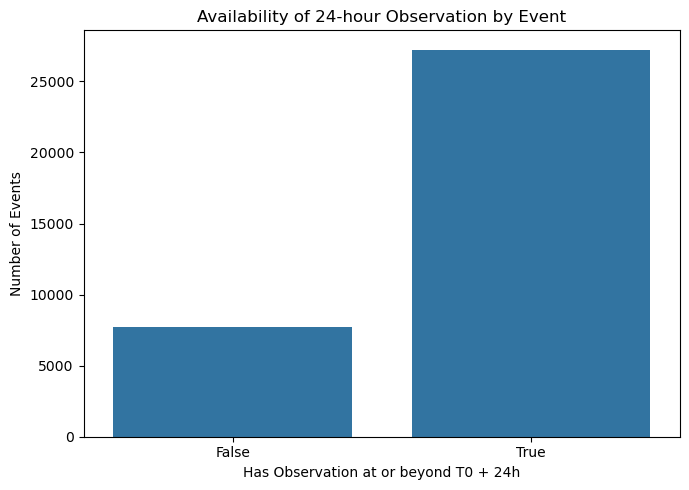

In [102]:
# 24시간 관측 가능 여부
plt.figure(figsize=(7, 5))

sns.countplot(
    data=view_growth,
    x='has_24h_observation'
)

plt.title('Availability of 24-hour Observation by Event')
plt.xlabel('Has Observation at or beyond T0 + 24h')
plt.ylabel('Number of Events')
plt.tight_layout()
plt.show()

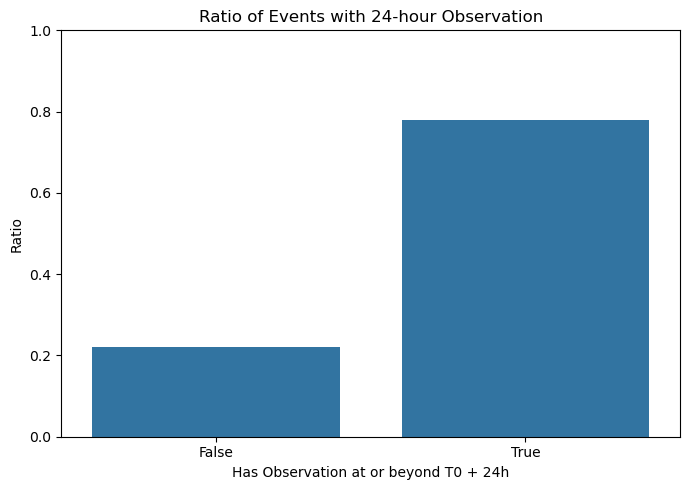

In [103]:
# 24시간 관측 가능 여부 비율
obs_ratio = (
    view_growth['has_24h_observation']
    .value_counts(normalize=True)
    .rename_axis('has_24h_observation')
    .reset_index(name='ratio')
)

plt.figure(figsize=(7, 5))

sns.barplot(
    data=obs_ratio,
    x='has_24h_observation',
    y='ratio'
)

plt.title('Ratio of Events with 24-hour Observation')
plt.xlabel('Has Observation at or beyond T0 + 24h')
plt.ylabel('Ratio')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

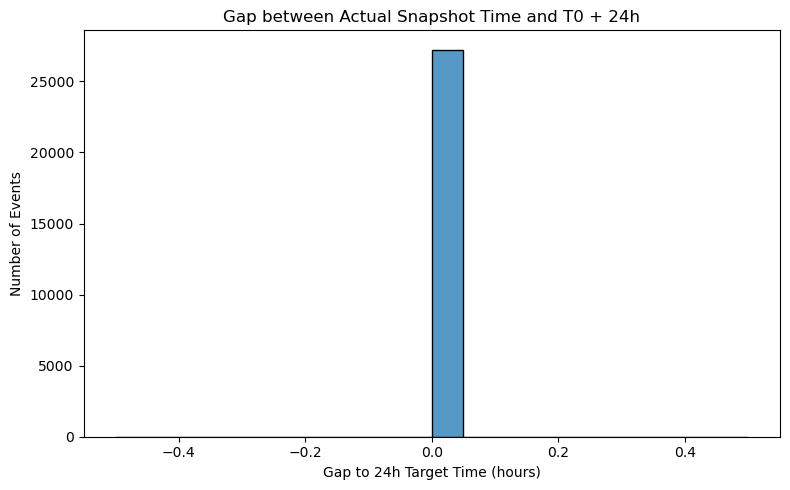

In [104]:
# 0이면 정확히 T0+24h 스냅샷을 사용한 것
# 6이면 T0+18h 스냅샷을 사용한 것
# 0에 몰려있으니 정상이다

# view_growth_24h 원자료 분포
plt.figure(figsize=(8, 5))

sns.histplot(
    view_growth.loc[view_growth['has_24h_observation'], 'actual_gap_to_24h'].dropna(),
    bins=20
)

plt.title('Gap between Actual Snapshot Time and T0 + 24h')
plt.xlabel('Gap to 24h Target Time (hours)')
plt.ylabel('Number of Events')
plt.tight_layout()
plt.show()



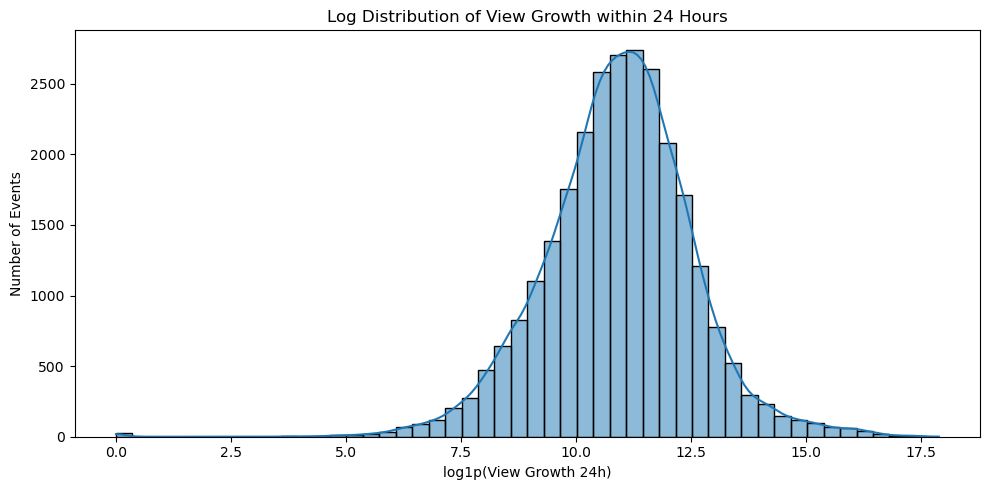

In [105]:
# view_growth_24h 로그 분포
plt.figure(figsize=(10, 5))

sns.histplot(
    view_growth['view_growth_24h_log'].dropna(),
    bins=50,
    kde=True
)

plt.title('Log Distribution of View Growth within 24 Hours')
plt.xlabel('log1p(View Growth 24h)')
plt.ylabel('Number of Events')
plt.tight_layout()
plt.show()

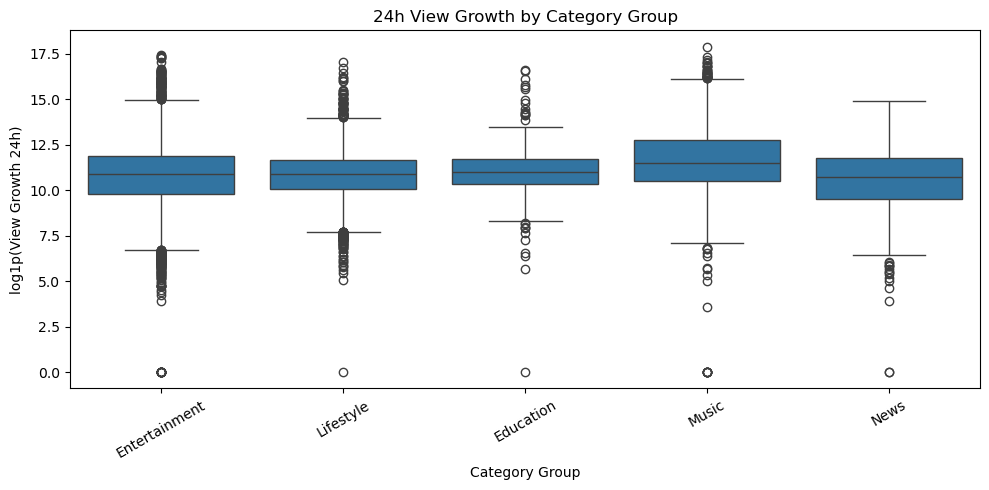

In [106]:
# 카테고리별 view_growth_24h 분포
# 이벤트별 category_group 붙이기
event_category = (
    df[event_key + ['category_group']]
    .drop_duplicates(event_key)
)

view_growth_cat = view_growth.merge(
    event_category,
    on=event_key,
    how='left'
)

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=view_growth_cat.dropna(subset=['view_growth_24h']),
    x='category_group',
    y='view_growth_24h_log'
)

plt.title('24h View Growth by Category Group')
plt.xlabel('Category Group')
plt.ylabel('log1p(View Growth 24h)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

,n_events,n_has_24h,has_24h_ratio
category_group,,,
Lifestyle,8497,6886,0.810404
Education,593,470,0.792580
Entertainment,19646,15230,0.775221
Music,5241,3933,0.750429
News,987,715,0.724417


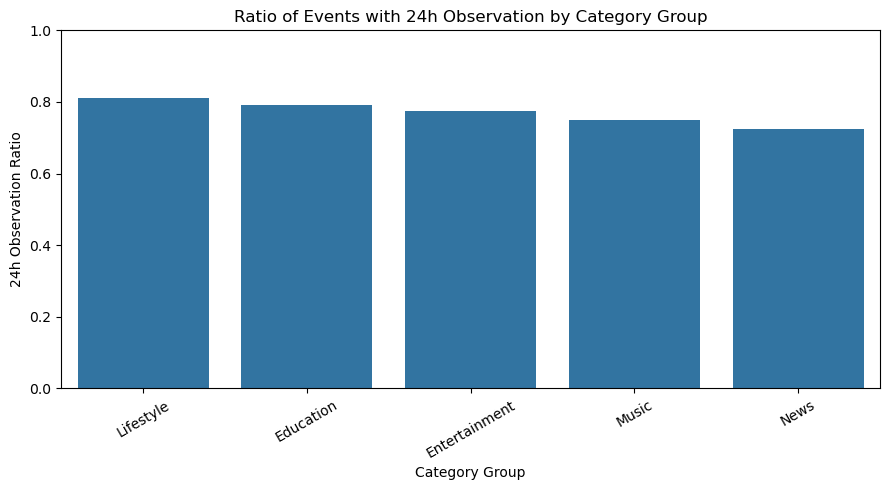

In [107]:
# 카테고리별 24시간 관측 가능 비율
cat_obs_ratio = (
    view_growth_cat
    .groupby('category_group')['has_24h_observation']
    .agg(['count', 'sum', 'mean'])
    .rename(columns={
        'count': 'n_events',
        'sum': 'n_has_24h',
        'mean': 'has_24h_ratio'
    })
    .sort_values('has_24h_ratio', ascending=False)
)

display(cat_obs_ratio)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=cat_obs_ratio.reset_index(),
    x='category_group',
    y='has_24h_ratio'
)

plt.title('Ratio of Events with 24h Observation by Category Group')
plt.xlabel('Category Group')
plt.ylabel('24h Observation Ratio')
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [108]:
# 카테고리별 view_growth_24h 요약표
growth_summary_by_cat = (
    view_growth_cat
    .dropna(subset=['view_growth_24h'])
    .groupby('category_group')
    .agg(
        n_events=('view_growth_24h', 'size'),
        mean_growth=('view_growth_24h', 'mean'),
        median_growth=('view_growth_24h', 'median'),
        q75_growth=('view_growth_24h', lambda x: x.quantile(0.75)),
        max_growth=('view_growth_24h', 'max'),
        mean_log_growth=('view_growth_24h_log', 'mean'),
        median_log_growth=('view_growth_24h_log', 'median')
    )
    .sort_values('median_log_growth', ascending=False)
)

display(growth_summary_by_cat)

,n_events,mean_growth,median_growth,q75_growth,max_growth,mean_log_growth,median_log_growth
category_group,,,,,,,
Music,3933,636767.730994,98946.0,339091.00,58266082.0,11.645795,11.502340
Education,470,245771.442553,60155.5,122551.75,16083105.0,10.972666,11.004705
Lifestyle,6886,128143.545309,54793.0,114453.00,25420177.0,10.831940,10.911336
Entertainment,15230,191750.092580,53178.0,142921.00,36194627.0,10.779843,10.881419
News,715,122792.591608,44431.0,126389.00,2871360.0,10.539963,10.701715


In [109]:
# =========================
# Step 5. 이벤트 단위 집계 + 기본 파생변수 생성 + 누수 점검
# =========================

# 목적:
# - snapshot 단위 df를 video_id + event_id 기준의 이벤트 단위 테이블로 변환
# - 이후 RQ1, RQ2, RQ3, RQ4 분석의 기본 단위로 사용
# - T0 시점 예측 가능 변수와 사후 분석용 변수를 명확히 구분
#
# 주의:
# - best_rank, peak_view, T_end_view, T_end_comment, n_snapshots,
#   is_single_snapshot, has_24h_observation 등은 예측 피처로 사용 금지
# - view_growth_24h는 T0 모델이 아니라 24h 모델에서만 사용 가능
# - engagement는 반드시 T0 기준으로 계산해야 누수가 아님

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

event_key = ['video_id', 'event_id']

# ---------------------------------------------------------
# 1. 정렬
# ---------------------------------------------------------
# first/last 집계가 정확히 작동하려면 반드시 시간순 정렬 필요
df = df.sort_values(event_key + ['collection_date']).copy()

# ---------------------------------------------------------
# 2. 숫자형 변환
# ---------------------------------------------------------
num_cols = ['view_count', 'comment_count', 'rank', 'category_id']

for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 필수 수치 결측 제거
df = df.dropna(subset=['view_count', 'comment_count', 'rank', 'category_id'])

df['view_count'] = df['view_count'].astype(float)
df['comment_count'] = df['comment_count'].astype(float)
df['rank'] = df['rank'].astype(float)
df['category_id'] = df['category_id'].astype(int)

# ---------------------------------------------------------
# 3. 이벤트 내부 메타데이터 일관성 점검
# ---------------------------------------------------------
category_consistency = df.groupby(event_key)['category_group'].nunique()
published_consistency = df.groupby(event_key)['published_at'].nunique()

print("[이벤트 내부 category_group이 2개 이상인 경우]")
print((category_consistency > 1).sum())

print("\n[이벤트 내부 published_at이 2개 이상인 경우]")
print((published_consistency > 1).sum())

# ---------------------------------------------------------
# 4. 이벤트 단위 집계
# ---------------------------------------------------------
events = (
    df.groupby(event_key)
      .agg(
          # 시간 정보
          T0=('collection_date', 'min'),
          T_end=('collection_date', 'max'),
          n_snapshots=('collection_date', 'count'),

          # 영상/채널 정보
          channel_id=('channel_id', 'first'),
          channel_title=('channel_title', 'first'),
          title=('title', 'first'),
          published_at=('published_at', 'first'),

          # 카테고리 정보
          category_id=('category_id', 'first'),
          category_group=('category_group', 'first'),

          # 초기 시점 변수: T0 예측 모델에서 사용 가능
          entry_rank=('rank', 'first'),
          T0_view=('view_count', 'first'),
          T0_comment=('comment_count', 'first'),

          # 사후 정보: 분석용만 사용, 예측 피처 사용 금지
          best_rank=('rank', 'min'),
          peak_view=('view_count', 'max'),
          T_end_view=('view_count', 'last'),
          T_end_comment=('comment_count', 'last')
      )
      .reset_index()
)

# ---------------------------------------------------------
# 5. 지속 시간 타겟 생성
# ---------------------------------------------------------
events['trending_duration_h_raw'] = (
    events['T_end'] - events['T0']
).dt.total_seconds() / 3600

events['is_single_snapshot'] = (
    events['trending_duration_h_raw'] == 0
).astype(int)

# 단일 스냅샷 이벤트는 최소 관측 단위 6시간으로 보정
events['trending_duration_h'] = (
    events['trending_duration_h_raw'].clip(lower=6)
)

events['trending_duration_log'] = np.log1p(events['trending_duration_h'])

# ---------------------------------------------------------
# 6. T0 기준 초기 반응 파생변수
# ---------------------------------------------------------
# 조회수/댓글수는 꼬리가 길기 때문에 로그 변환 사용 권장
events['T0_view_log'] = np.log1p(events['T0_view'])
events['T0_comment_log'] = np.log1p(events['T0_comment'])

# T0 기준 engagement ratio
# T0_comment / T0_view 이므로 트렌딩 진입 시점에 알 수 있는 정보 → 누수 아님
events['T0_engagement_ratio'] = (
    events['T0_comment'] / events['T0_view'].replace(0, np.nan)
)

events['T0_engagement_ratio_log'] = np.log1p(events['T0_engagement_ratio'])

# 극단값 확인용 분위수
print("\n[T0_engagement_ratio 분위수]")
print(events['T0_engagement_ratio'].quantile([0, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999, 1]))

# ---------------------------------------------------------
# 7. 업로드 후 트렌딩 진입까지 걸린 시간
# ---------------------------------------------------------
events['latency_to_trend_h'] = (
    events['T0'] - events['published_at']
).dt.total_seconds() / 3600

print("\n[latency_to_trend_h 음수 개수]")
print((events['latency_to_trend_h'] < 0).sum())

# 음수 latency는 시간대/수집 오류 가능성이 있으므로 0으로 보정
events['latency_to_trend_h'] = events['latency_to_trend_h'].clip(lower=0)
events['latency_to_trend_log'] = np.log1p(events['latency_to_trend_h'])

# ---------------------------------------------------------
# 8. 업로드 시간 변수
# ---------------------------------------------------------
events['published_weekday'] = events['published_at'].dt.dayofweek
events['published_hour'] = events['published_at'].dt.hour

# 시간은 순환형 변수이므로 sin/cos 변환
events['hour_sin'] = np.sin(2 * np.pi * events['published_hour'] / 24)
events['hour_cos'] = np.cos(2 * np.pi * events['published_hour'] / 24)

# ---------------------------------------------------------
# 9. Step 4 view_growth_24h 병합
# ---------------------------------------------------------
# view_growth_24h는 진입 후 24시간이 지나야 알 수 있으므로
# T0 모델에서는 사용 금지, 24h 모델에서만 사용 가능

if 'view_growth' in globals():
    view_growth_cols = [
        'video_id', 'event_id',
        'view_at_24h',
        'view_growth_24h',
        'view_growth_24h_log',
        'has_24h_observation',
        'has_exact_24h_snapshot',
        'actual_time_at_24h',
        'actual_gap_to_24h'
    ]

    existing_cols = [c for c in view_growth_cols if c in view_growth.columns]

    events = events.merge(
        view_growth[existing_cols],
        on=event_key,
        how='left'
    )

    print("\n[view_growth 병합 완료]")
else:
    print("\n[주의] view_growth 객체가 없어 Step 4 변수는 병합하지 않았습니다.")

# ---------------------------------------------------------
# 10. 사후 정보 이상값 확인
# ---------------------------------------------------------
# 아래 변수들은 분석용 확인에는 사용 가능하지만 예측 피처로는 사용 금지

print("\n[T_end_view < T0_view 이벤트 수]")
print((events['T_end_view'] < events['T0_view']).sum())

print("\n[T_end_comment < T0_comment 이벤트 수]")
print((events['T_end_comment'] < events['T0_comment']).sum())

print("\n[best_rank > entry_rank 이벤트 수]")
print((events['best_rank'] > events['entry_rank']).sum())
# best_rank는 rank min이므로 entry_rank보다 숫자가 커질 수 없음. 0이어야 정상.

# ---------------------------------------------------------
# 11. 기본 결과 확인
# ---------------------------------------------------------
print("\n[events shape]")
print(events.shape)

print("\n[trending_duration_h 요약]")
print(events['trending_duration_h'].describe())

print("\n[n_snapshots 요약]")
print(events['n_snapshots'].describe())

print("\n[단일 스냅샷 이벤트 수]")
print(events['is_single_snapshot'].value_counts(dropna=False))

print("\n[카테고리별 이벤트 수]")
print(events['category_group'].value_counts(dropna=False))

print("\n[결측치 상위]")
print(events.isnull().sum().sort_values(ascending=False).head(20))

display(events.head())

[이벤트 내부 category_group이 2개 이상인 경우]
21

[이벤트 내부 published_at이 2개 이상인 경우]
0

[T0_engagement_ratio 분위수]
0.000    0.000000
0.500    0.001809
0.750    0.003350
0.900    0.006239
0.950    0.009085
0.990    0.018686
0.999    0.035682
1.000    0.302909
Name: T0_engagement_ratio, dtype: float64

[latency_to_trend_h 음수 개수]
131

[view_growth 병합 완료]

[T_end_view < T0_view 이벤트 수]
23

[T_end_comment < T0_comment 이벤트 수]
1211

[best_rank > entry_rank 이벤트 수]
0

[events shape]
(34964, 39)

[trending_duration_h 요약]
count    34964.000000
mean       144.116177
std        127.864086
min          6.000000
25%         30.000000
50%        108.000000
75%        240.000000
max        768.000000
Name: trending_duration_h, dtype: float64

[n_snapshots 요약]
count    34964.000000
mean        24.945401
std         21.392027
min          1.000000
25%          6.000000
50%         19.000000
75%         41.000000
max        129.000000
Name: n_snapshots, dtype: float64

[단일 스냅샷 이벤트 수]
is_single_snapshot
0    32378
1     

,video_id,event_id,T0,T_end,n_snapshots,channel_id,channel_title,title,published_at,category_id,...,published_hour,hour_sin,hour_cos,view_at_24h,view_growth_24h,view_growth_24h_log,has_24h_observation,has_exact_24h_snapshot,actual_time_at_24h,actual_gap_to_24h
0,--24T6TzQvc,1,2023-11-11 15:00:00,2023-11-11 21:00:00,2,UCl_tB4AqPkkxuYcJQHz6dMw,EBSCulture (EBS 교양),[Full] 왔다! 내 손주 - 프랑스에서 날아온 네 손주 (1),2023-11-10 15:00:00,24,...,15,-0.707107,-0.707107,211239,NaN,NaN,False,False,2023-11-11 21:00:00,18.0
1,--24T6TzQvc,2,2023-11-13 09:00:00,2023-11-22 15:00:00,38,UCl_tB4AqPkkxuYcJQHz6dMw,EBSCulture (EBS 교양),[Full] 왔다! 내 손주 - 프랑스에서 날아온 네 손주 (1),2023-11-10 15:00:00,24,...,15,-0.707107,-0.707107,350376,40107.0,10.599331,True,True,2023-11-14 09:00:00,0.0
2,--m5TieGS6Y,1,2022-11-12 15:00:00,2022-11-24 09:00:00,48,UCzIOIStANWRgYa3BRuJOg8Q,주부나라,밥통에 사과를 넣었더니 그립던 옛맛에 눈물이 납니다,2022-11-10 19:54:30,26,...,19,-0.965926,0.258819,997474,239834.0,12.387706,True,True,2022-11-13 15:00:00,0.0
3,-0ICh3CmHVs,1,2025-06-08 15:00:00,2025-06-11 09:00:00,12,UCsjD7wxKCD8C62_idZQdGJg,The CHOOM (더 춤),[EN/JP] [#WSWF/3회 선공개] 리더 계급 메인 댄서? 뺏어줄게!,2025-06-07 23:00:00,24,...,23,-0.258819,0.965926,1171081,259352.0,12.465945,True,True,2025-06-09 15:00:00,0.0
4,-0JLHPtFhNM,1,2022-10-26 21:00:00,2022-10-29 15:00:00,12,UCepUWUpH45hRTi-QePdq1Bg,Mnet TV,[ENG] [#SMTM11/1회 선공개] '피하고 싶은 스승이냐 만나고 싶은 최애냐...,2022-10-21 19:53:55,24,...,19,-0.965926,0.258819,851753,9750.0,9.185125,True,True,2022-10-27 21:00:00,0.0


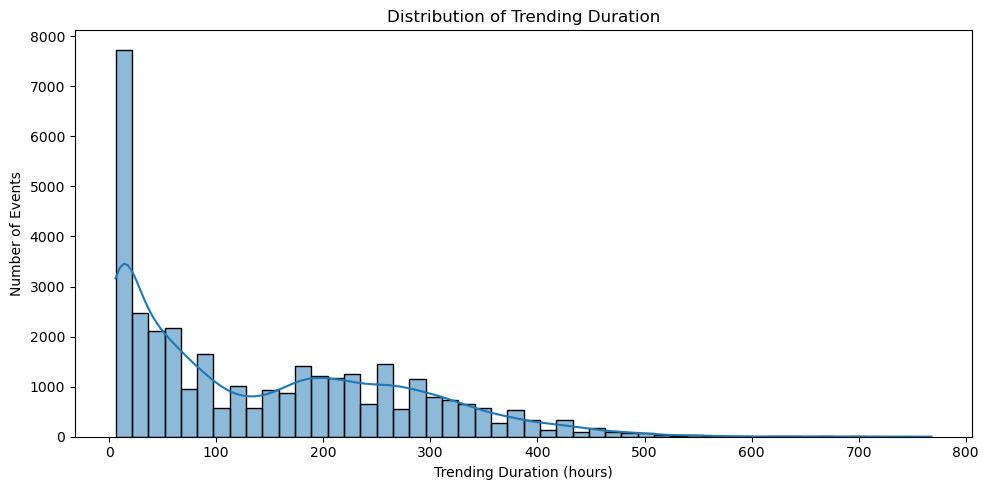

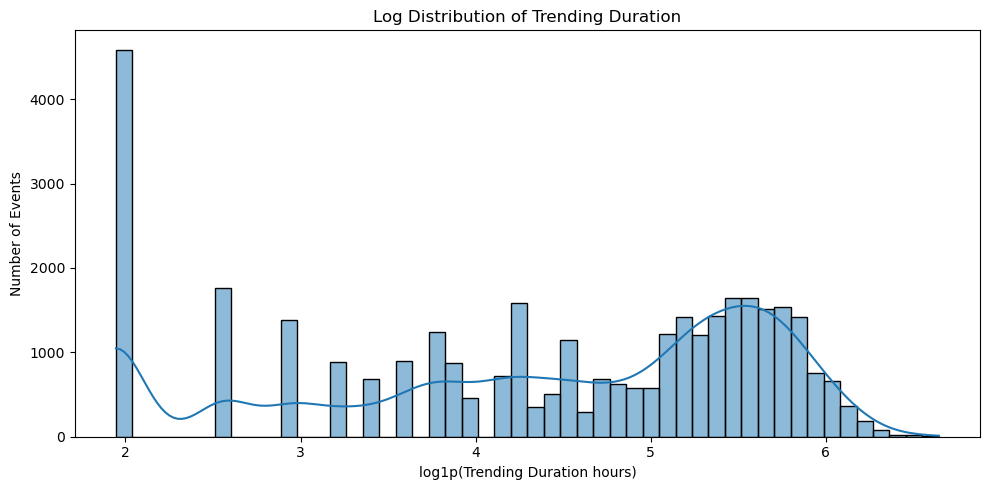

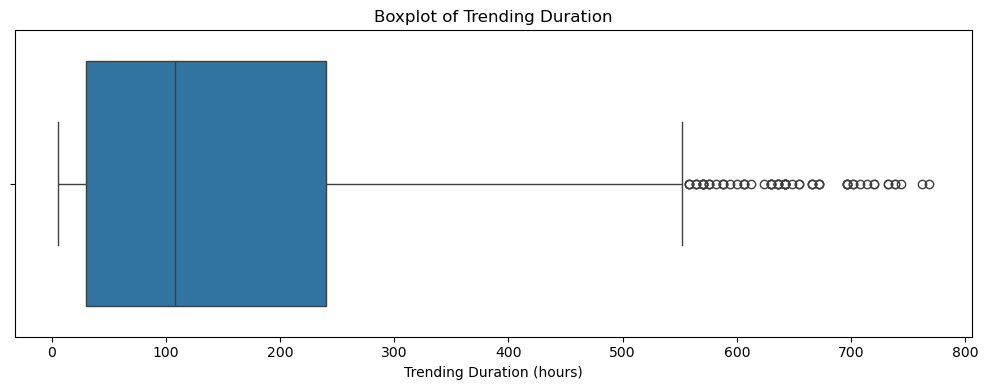

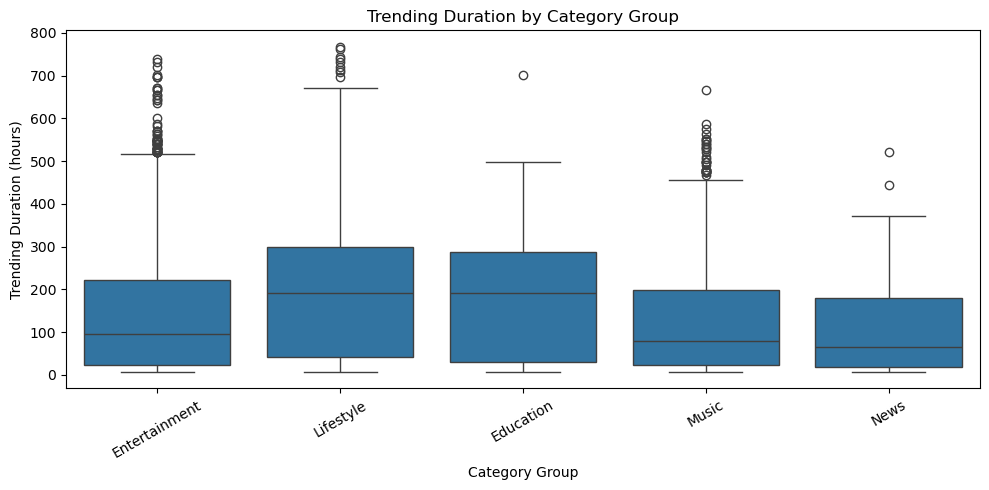

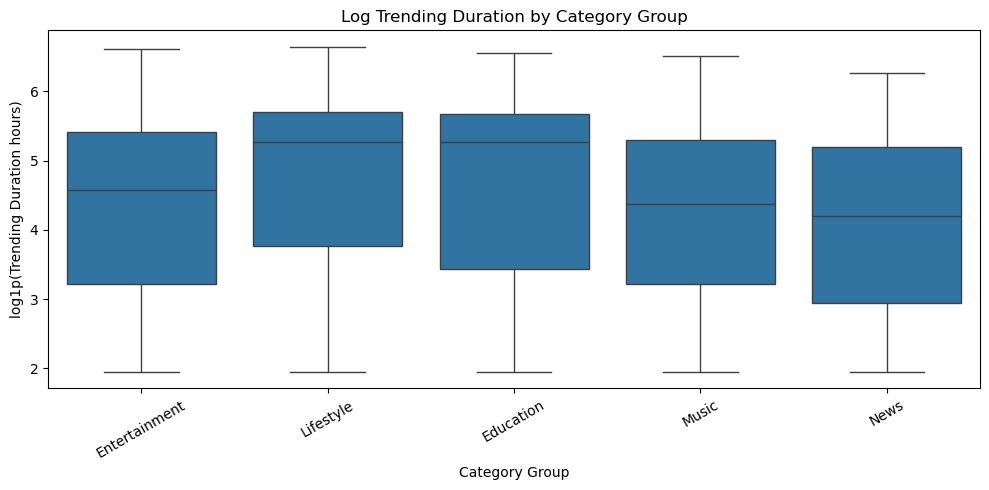

,n,mean,median,std,min,q25,q75,q90,q95,max
category_group,,,,,,,,,,
Education,593,175.072513,192.0,135.501109,6.0,30.0,288.0,348.0,384.0,702.0
Lifestyle,8497,185.725315,192.0,143.478505,6.0,42.0,300.0,378.0,420.0,768.0
Entertainment,19646,134.475618,96.0,121.999334,6.0,24.0,222.0,312.0,360.0,738.0
Music,5241,117.460790,78.0,109.203515,6.0,24.0,198.0,276.0,318.0,666.0
News,987,100.741641,66.0,91.644526,6.0,18.0,180.0,234.0,258.0,522.0


,n_events,n_single_snapshot,single_snapshot_ratio
category_group,,,
Music,5241,461,0.087960
News,987,79,0.080041
Education,593,45,0.075885
Entertainment,19646,1440,0.073297
Lifestyle,8497,561,0.066023


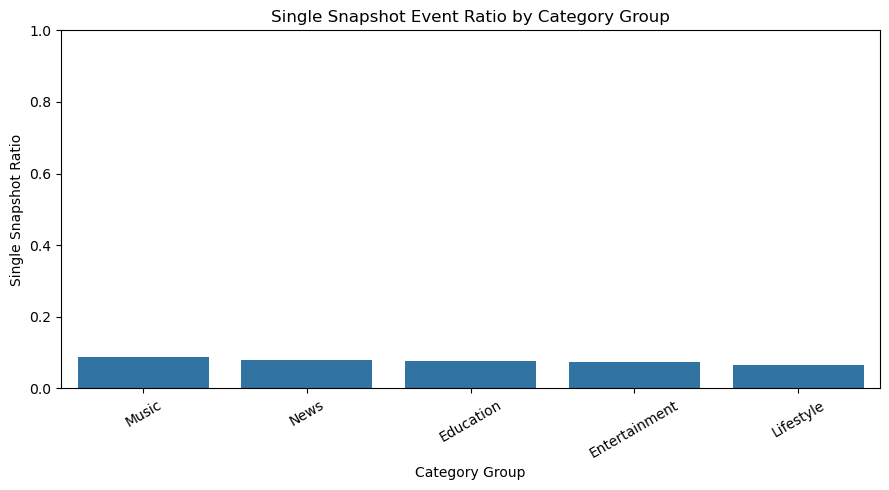

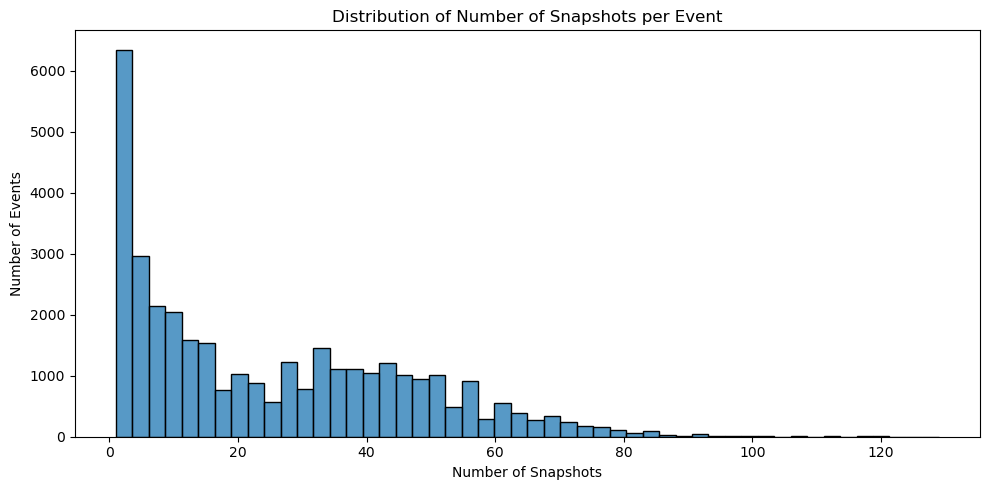

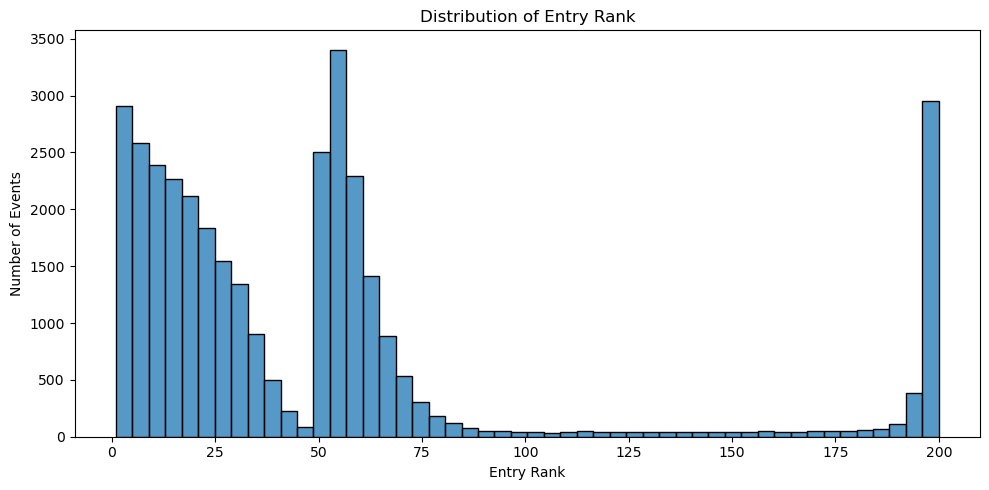

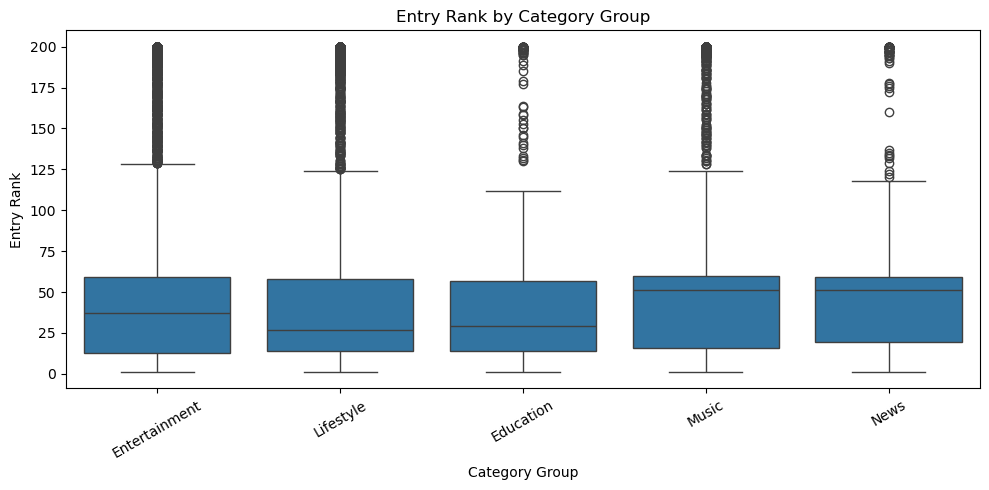

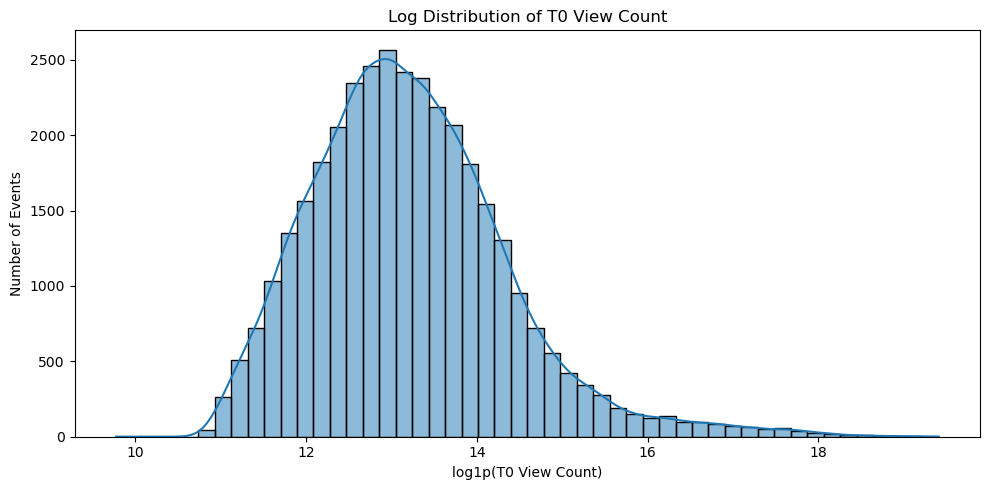

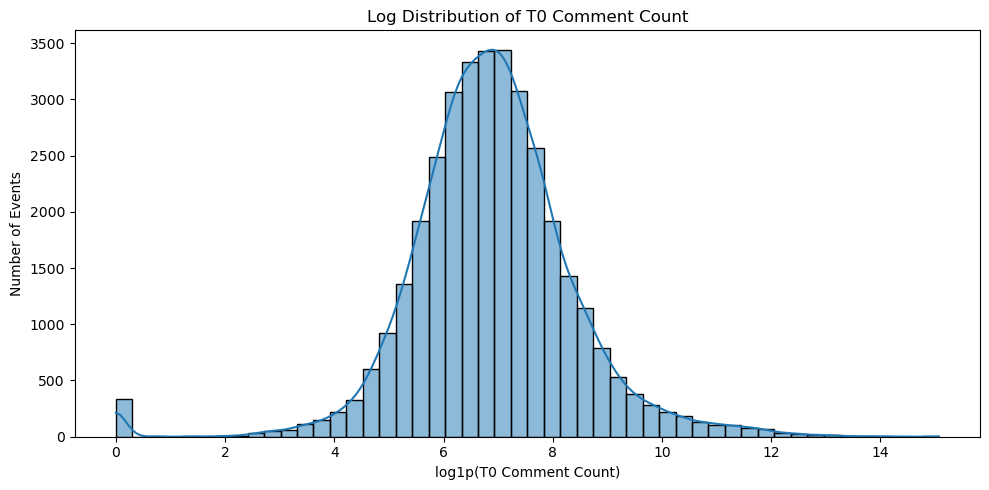

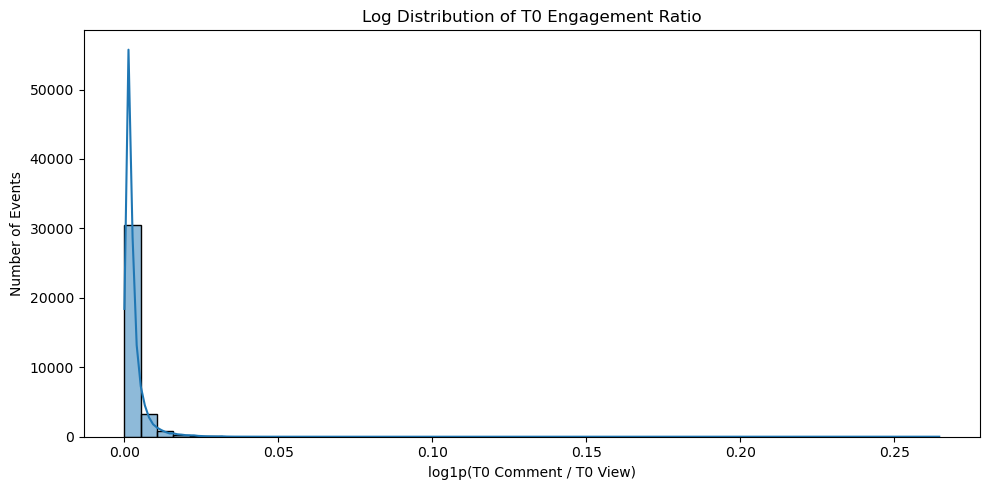

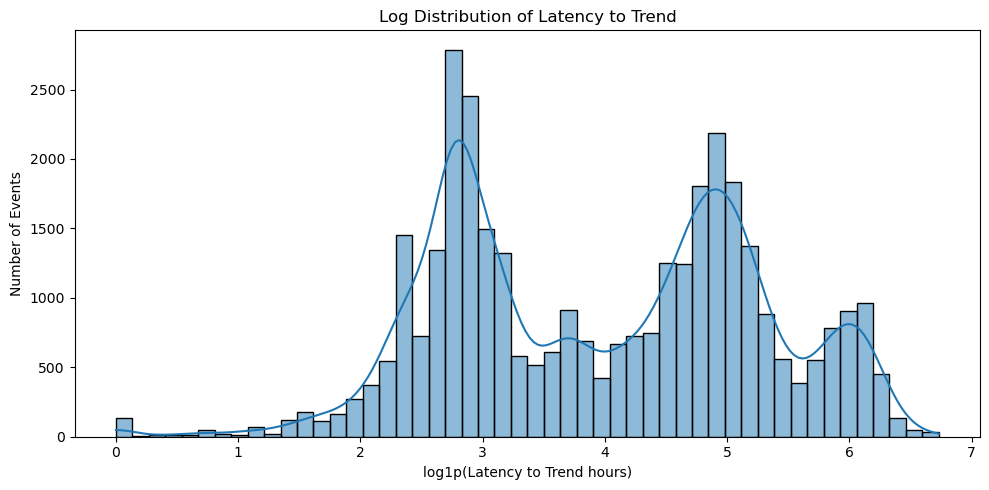

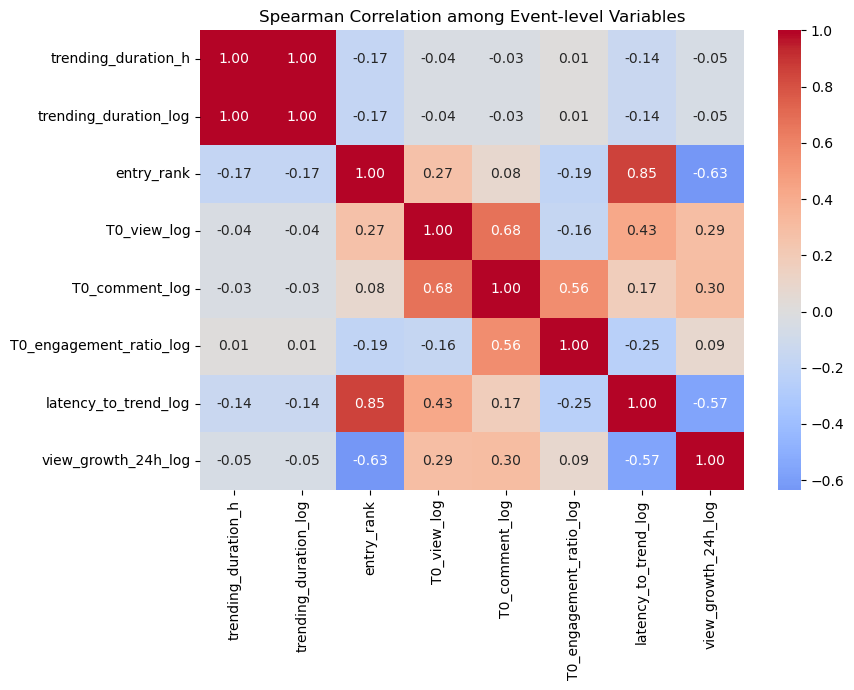

In [110]:
# =========================
# Step 5 EDA + 시각화
# =========================

# ---------------------------------------------------------
# 1. 이벤트 지속 시간 분포
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.histplot(events['trending_duration_h'], bins=50, kde=True)
plt.title('Distribution of Trending Duration')
plt.xlabel('Trending Duration (hours)')
plt.ylabel('Number of Events')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(events['trending_duration_log'], bins=50, kde=True)
plt.title('Log Distribution of Trending Duration')
plt.xlabel('log1p(Trending Duration hours)')
plt.ylabel('Number of Events')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2. 지속 시간 boxplot
# ---------------------------------------------------------
plt.figure(figsize=(10, 4))
sns.boxplot(x=events['trending_duration_h'])
plt.title('Boxplot of Trending Duration')
plt.xlabel('Trending Duration (hours)')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. 카테고리별 지속 시간 분포
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=events,
    x='category_group',
    y='trending_duration_h'
)
plt.title('Trending Duration by Category Group')
plt.xlabel('Category Group')
plt.ylabel('Trending Duration (hours)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=events,
    x='category_group',
    y='trending_duration_log'
)
plt.title('Log Trending Duration by Category Group')
plt.xlabel('Category Group')
plt.ylabel('log1p(Trending Duration hours)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. 카테고리별 지속 시간 요약표
# ---------------------------------------------------------
duration_by_cat = (
    events.groupby('category_group')['trending_duration_h']
    .agg(
        n='size',
        mean='mean',
        median='median',
        std='std',
        min='min',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        q90=lambda x: x.quantile(0.90),
        q95=lambda x: x.quantile(0.95),
        max='max'
    )
    .sort_values('median', ascending=False)
)

display(duration_by_cat)

# ---------------------------------------------------------
# 5. 단일 스냅샷 이벤트 비율
# ---------------------------------------------------------
single_ratio = (
    events.groupby('category_group')['is_single_snapshot']
    .agg(['count', 'sum', 'mean'])
    .rename(columns={
        'count': 'n_events',
        'sum': 'n_single_snapshot',
        'mean': 'single_snapshot_ratio'
    })
    .sort_values('single_snapshot_ratio', ascending=False)
)

display(single_ratio)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=single_ratio.reset_index(),
    x='category_group',
    y='single_snapshot_ratio'
)
plt.title('Single Snapshot Event Ratio by Category Group')
plt.xlabel('Category Group')
plt.ylabel('Single Snapshot Ratio')
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 6. 이벤트별 스냅샷 수 분포
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.histplot(events['n_snapshots'], bins=50)
plt.title('Distribution of Number of Snapshots per Event')
plt.xlabel('Number of Snapshots')
plt.ylabel('Number of Events')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 7. entry_rank 분포
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.histplot(events['entry_rank'], bins=50)
plt.title('Distribution of Entry Rank')
plt.xlabel('Entry Rank')
plt.ylabel('Number of Events')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=events,
    x='category_group',
    y='entry_rank'
)
plt.title('Entry Rank by Category Group')
plt.xlabel('Category Group')
plt.ylabel('Entry Rank')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 8. T0_view, T0_comment 분포
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.histplot(events['T0_view_log'], bins=50, kde=True)
plt.title('Log Distribution of T0 View Count')
plt.xlabel('log1p(T0 View Count)')
plt.ylabel('Number of Events')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(events['T0_comment_log'], bins=50, kde=True)
plt.title('Log Distribution of T0 Comment Count')
plt.xlabel('log1p(T0 Comment Count)')
plt.ylabel('Number of Events')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 9. T0_engagement_ratio 분포
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.histplot(events['T0_engagement_ratio_log'].dropna(), bins=50, kde=True)
plt.title('Log Distribution of T0 Engagement Ratio')
plt.xlabel('log1p(T0 Comment / T0 View)')
plt.ylabel('Number of Events')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 10. latency_to_trend 분포
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.histplot(events['latency_to_trend_log'], bins=50, kde=True)
plt.title('Log Distribution of Latency to Trend')
plt.xlabel('log1p(Latency to Trend hours)')
plt.ylabel('Number of Events')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 11. 초기 피처와 지속 시간 상관 확인
# ---------------------------------------------------------
corr_cols = [
    'trending_duration_h',
    'trending_duration_log',
    'entry_rank',
    'T0_view_log',
    'T0_comment_log',
    'T0_engagement_ratio_log',
    'latency_to_trend_log'
]

if 'view_growth_24h_log' in events.columns:
    corr_cols.append('view_growth_24h_log')

corr_df = events[corr_cols].corr(method='spearman')

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_df,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title('Spearman Correlation among Event-level Variables')
plt.tight_layout()
plt.show()

In [111]:
# =========================
# 모델별 사용 가능한 피처 정의
# =========================

# T0 모델:
# 트렌딩 진입 시점에 알 수 있는 변수만 사용
features_T0 = [
    'category_group',
    'entry_rank',
    'T0_view_log',
    'T0_comment_log',
    'T0_engagement_ratio_log',
    'latency_to_trend_log',
    'published_weekday',
    'hour_sin',
    'hour_cos'
]

# 24h 모델:
# has_24h_observation == True인 이벤트만 사용
# view_growth_24h_log 추가 가능
features_24h = [
    'category_group',
    'entry_rank',
    'T0_view_log',
    'T0_comment_log',
    'T0_engagement_ratio_log',
    'latency_to_trend_log',
    'published_weekday',
    'hour_sin',
    'hour_',
    'view_growth_24h_log'
]

# 예측 피처로 사용 금지
forbidden_features = [
    'video_id',
    'event_id',
    'T0',
    'T_end',
    'T_end_view',
    'T_end_comment',
    'best_rank',
    'peak_view',
    'trending_duration_h_raw',
    'trending_duration_h',
    'trending_duration_log',
    'n_snapshots',
    'is_single_snapshot',
    'view_at_24h',
    'has_24h_observation',
    'has_exact_24h_snapshot',
    'actual_time_at_24h',
    'actual_gap_to_24h'
]

print("[T0 모델 피처]")
print(features_T0)

print("\n[24h 모델 피처]")
print(features_24h)

print("\n[예측 피처 사용 금지 변수]")
print(forbidden_features)

[T0 모델 피처]
['category_group', 'entry_rank', 'T0_view_log', 'T0_comment_log', 'T0_engagement_ratio_log', 'latency_to_trend_log', 'published_weekday', 'hour_sin', 'hour_cos']

[24h 모델 피처]
['category_group', 'entry_rank', 'T0_view_log', 'T0_comment_log', 'T0_engagement_ratio_log', 'latency_to_trend_log', 'published_weekday', 'hour_sin', 'hour_', 'view_growth_24h_log']

[예측 피처 사용 금지 변수]
['video_id', 'event_id', 'T0', 'T_end', 'T_end_view', 'T_end_comment', 'best_rank', 'peak_view', 'trending_duration_h_raw', 'trending_duration_h', 'trending_duration_log', 'n_snapshots', 'is_single_snapshot', 'view_at_24h', 'has_24h_observation', 'has_exact_24h_snapshot', 'actual_time_at_24h', 'actual_gap_to_24h']


In [112]:
# =========================
# Step 6. 추가 파생 피처 정리 + 누수 방지 피처 리스트 확정
# =========================

# 전제:
# - Step 5에서 events 테이블 생성 완료
# - Step 5에서 아래 변수 생성 완료:
#   T0_view_log, T0_comment_log, T0_engagement_ratio,
#   T0_engagement_ratio_log, latency_to_trend_h,
#   latency_to_trend_log, published_weekday, published_hour,
#   hour_sin, hour_cos, view_growth_24h, view_growth_24h_log

import numpy as np
import pandas as pd
import re

events = events.copy()

# ---------------------------------------------------------
# 1. 필수 컬럼 존재 확인
# ---------------------------------------------------------
required_cols = [
    'video_id', 'event_id',
    'T0', 'T_end', 'published_at',
    'category_group',
    'entry_rank',
    'T0_view', 'T0_comment',
    'T_end_view', 'T_end_comment',
    'trending_duration_h',
    'T0_view_log', 'T0_comment_log',
    'T0_engagement_ratio_log',
    'latency_to_trend_h', 'latency_to_trend_log',
    'published_weekday', 'hour_sin', 'hour_cos'
]

missing_required = [c for c in required_cols if c not in events.columns]

if missing_required:
    print("[주의] Step 6 실행 전 필요한 컬럼이 없습니다:")
    print(missing_required)
else:
    print("[OK] Step 6 필수 컬럼 확인 완료")

# ---------------------------------------------------------
# 2. entry_rank_log 생성
# ---------------------------------------------------------
# rank는 낮을수록 좋은 순위
# log 변환은 rank의 비선형 효과 완화용
events['entry_rank'] = pd.to_numeric(events['entry_rank'], errors='coerce')
events['entry_rank_log'] = np.log1p(events['entry_rank'])

# ---------------------------------------------------------
# 3. pretrend_view_velocity 생성
# ---------------------------------------------------------
# 의미:
# - 업로드 후 트렌딩 진입 전까지 조회수가 얼마나 빠르게 축적되었는가
# - T0_view / latency_to_trend_h
# - T0 시점에 알 수 있으므로 누수 아님
#
# 주의:
# - latency가 0에 가까우면 값이 폭발할 수 있으므로 safe 값 사용

events['latency_to_trend_h_safe'] = events['latency_to_trend_h'].clip(lower=1)

events['pretrend_view_velocity'] = (
    events['T0_view'] / events['latency_to_trend_h_safe']
)

events['pretrend_view_velocity_log'] = np.log1p(events['pretrend_view_velocity'])

# ---------------------------------------------------------
# 4. 한국어 제목 여부
# ---------------------------------------------------------
# KR 트렌딩 전체 분석에서는 핵심 피처로 사용하지 않음
# 검사용 또는 보조 분석용으로만 사용

def has_korean(text):
    if pd.isna(text):
        return 0
    return int(bool(re.search(r'[가-힣]', str(text))))

events['has_korean_title'] = events['title'].apply(has_korean)

# ---------------------------------------------------------
# 5. 사후 분석용 변수 생성
# ---------------------------------------------------------
# 예측 피처 사용 금지
# 종료 후에야 알 수 있는 T_end_view와 타겟 duration을 사용하기 때문

events['observed_view_velocity'] = (
    (events['T_end_view'] - events['T0_view'])
    / events['trending_duration_h'].replace(0, np.nan)
).clip(lower=0)

events['observed_comment_growth'] = (
    events['T_end_comment'] - events['T0_comment']
).clip(lower=0)

# ---------------------------------------------------------
# 6. EDA용 winsorization
# ---------------------------------------------------------
# 모델링용이 아니라 EDA/시각화 안정화용
# 모델링에서는 train set 기준으로 별도 처리해야 함

def winsorize_for_eda(series, lower=0.01, upper=0.99):
    q_low = series.quantile(lower)
    q_high = series.quantile(upper)
    return series.clip(q_low, q_high)

events['trending_duration_h_wins_eda'] = winsorize_for_eda(
    events['trending_duration_h']
)

events['T0_engagement_ratio_wins_eda'] = winsorize_for_eda(
    events['T0_engagement_ratio']
)

events['pretrend_view_velocity_wins_eda'] = winsorize_for_eda(
    events['pretrend_view_velocity']
)

events['view_growth_24h_wins_eda'] = np.nan

if 'view_growth_24h' in events.columns:
    mask_24h = events['view_growth_24h'].notna()
    events.loc[mask_24h, 'view_growth_24h_wins_eda'] = winsorize_for_eda(
        events.loc[mask_24h, 'view_growth_24h']
    )

# ---------------------------------------------------------
# 7. 모델별 피처 리스트 확정
# ---------------------------------------------------------

features_T0 = [
    'category_group',
    'entry_rank_log',
    'T0_view_log',
    'T0_comment_log',
    'T0_engagement_ratio_log',
    'latency_to_trend_log',
    'pretrend_view_velocity_log',
    'published_weekday',
    'hour_sin',
    'hour_cos'
]

features_24h = [
    'category_group',
    'entry_rank_log',
    'T0_view_log',
    'T0_comment_log',
    'T0_engagement_ratio_log',
    'latency_to_trend_log',
    'pretrend_view_velocity_log',
    'published_weekday',
    'hour_sin',
    'hour_cos',
    'view_growth_24h_log'
]

forbidden_features = [
    # identifiers / keys
    'video_id',
    'event_id',

    # time keys
    'T0',
    'T_end',

    # target
    'trending_duration_h',
    'trending_duration_h_raw',
    'trending_duration_log',
    'trending_duration_h_wins_eda',

    # direct duration proxies
    'n_snapshots',
    'is_single_snapshot',
    'has_24h_observation',
    'has_exact_24h_snapshot',
    'actual_time_at_24h',
    'actual_gap_to_24h',

    # future / post-event information
    'best_rank',
    'peak_view',
    'T_end_view',
    'T_end_comment',
    'observed_view_velocity',
    'observed_comment_growth',

    # 24h variables not allowed in T0 model
    'view_at_24h',
    'view_growth_24h',
    'view_growth_24h_log'
]

# ---------------------------------------------------------
# 8. 누수 피처가 features_T0에 들어갔는지 확인
# ---------------------------------------------------------
leak_in_T0 = [c for c in features_T0 if c in forbidden_features]
leak_in_24h = [
    c for c in features_24h
    if c in forbidden_features and c != 'view_growth_24h_log'
]

print("\n[누수 점검]")
print("T0 피처 내 금지 변수:", leak_in_T0)
print("24h 피처 내 금지 변수:", leak_in_24h)

# ---------------------------------------------------------
# 9. 24h 모델 데이터셋 생성 가능 여부 확인
# ---------------------------------------------------------
if 'has_24h_observation' in events.columns:
    events_T0 = events.copy()
    events_24h = events[events['has_24h_observation'] == True].copy()

    print("\n[T0 모델 데이터 크기]")
    print(events_T0.shape)

    print("\n[24h 모델 데이터 크기]")
    print(events_24h.shape)
else:
    print("\n[주의] has_24h_observation 컬럼이 없어 events_24h를 생성하지 않았습니다.")

# ---------------------------------------------------------
# 10. 기본 요약 확인
# ---------------------------------------------------------
check_cols = [
    'entry_rank_log',
    'T0_view_log',
    'T0_comment_log',
    'T0_engagement_ratio_log',
    'latency_to_trend_log',
    'pretrend_view_velocity_log'
]

if 'view_growth_24h_log' in events.columns:
    check_cols.append('view_growth_24h_log')

print("\n[주요 파생 피처 요약]")
display(events[check_cols].describe())

print("\n[결측치 상위]")
display(events.isnull().sum().sort_values(ascending=False).head(30))

print("\n[T0 모델 피처]")
print(features_T0)

print("\n[24h 모델 피처]")
print(features_24h)

[OK] Step 6 필수 컬럼 확인 완료

[누수 점검]
T0 피처 내 금지 변수: []
24h 피처 내 금지 변수: []

[T0 모델 데이터 크기]
(34964, 50)

[24h 모델 데이터 크기]
(27234, 50)

[주요 파생 피처 요약]


,entry_rank_log,T0_view_log,T0_comment_log,T0_engagement_ratio_log,latency_to_trend_log,pretrend_view_velocity_log,view_growth_24h_log
count,34964.000000,34964.000000,34964.000000,34964.000000,34964.000000,34964.000000,27234.000000
mean,3.438118,13.213606,6.872637,0.002911,3.971205,9.282033,10.915102
std,1.123039,1.154665,1.530536,0.003853,1.284901,1.374234,1.620658
min,0.693147,9.771783,0.000000,0.000000,0.000000,4.300620,0.000000
25%,2.708050,12.414134,6.045005,0.001003,2.832658,8.320501,9.964877
50%,3.555348,13.104729,6.849066,0.001807,4.053407,9.156623,10.967224
75%,4.094345,13.861778,7.686162,0.003345,5.003903,10.102699,11.901155
max,5.303305,19.411860,15.069899,0.264599,6.731125,17.497530,17.880531



[결측치 상위]


view_growth_24h_wins_eda           7730
view_growth_24h                    7730
view_growth_24h_log                7730
actual_time_at_24h                    0
latency_to_trend_log                  0
published_weekday                     0
published_hour                        0
hour_sin                              0
hour_cos                              0
view_at_24h                           0
has_24h_observation                   0
has_exact_24h_snapshot                0
actual_gap_to_24h                     0
event_id                              0
entry_rank_log                        0
latency_to_trend_h_safe               0
pretrend_view_velocity                0
pretrend_view_velocity_log            0
has_korean_title                      0
observed_view_velocity                0
observed_comment_growth               0
trending_duration_h_wins_eda          0
T0_engagement_ratio_wins_eda          0
pretrend_view_velocity_wins_eda       0
latency_to_trend_h                    0



[T0 모델 피처]
['category_group', 'entry_rank_log', 'T0_view_log', 'T0_comment_log', 'T0_engagement_ratio_log', 'latency_to_trend_log', 'pretrend_view_velocity_log', 'published_weekday', 'hour_sin', 'hour_cos']

[24h 모델 피처]
['category_group', 'entry_rank_log', 'T0_view_log', 'T0_comment_log', 'T0_engagement_ratio_log', 'latency_to_trend_log', 'pretrend_view_velocity_log', 'published_weekday', 'hour_sin', 'hour_cos', 'view_growth_24h_log']


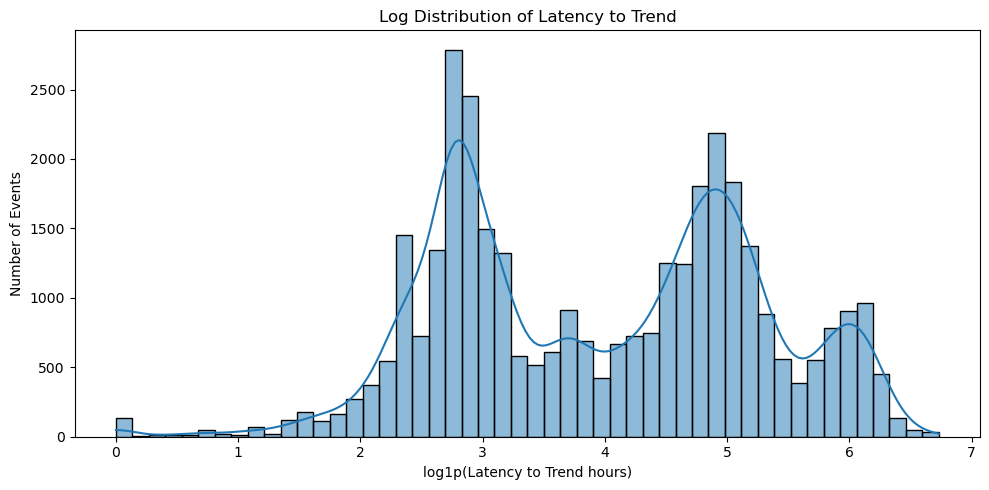

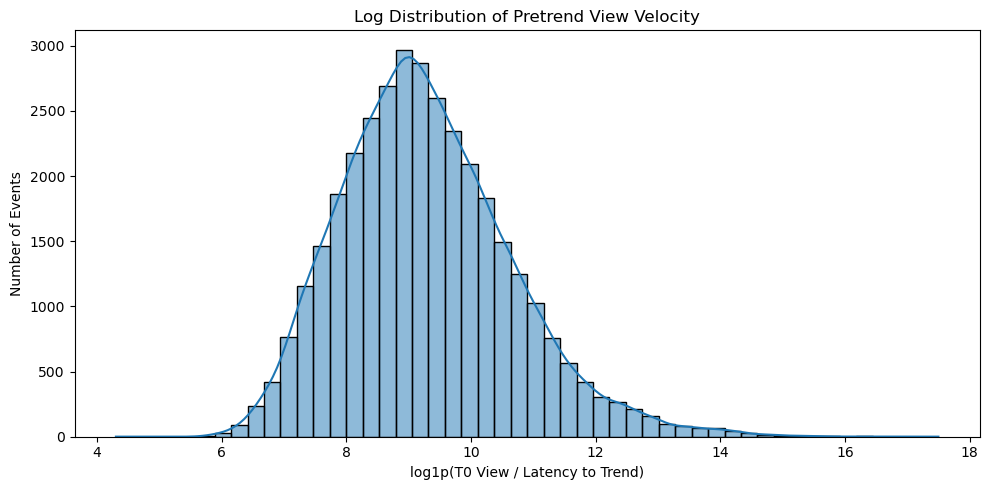

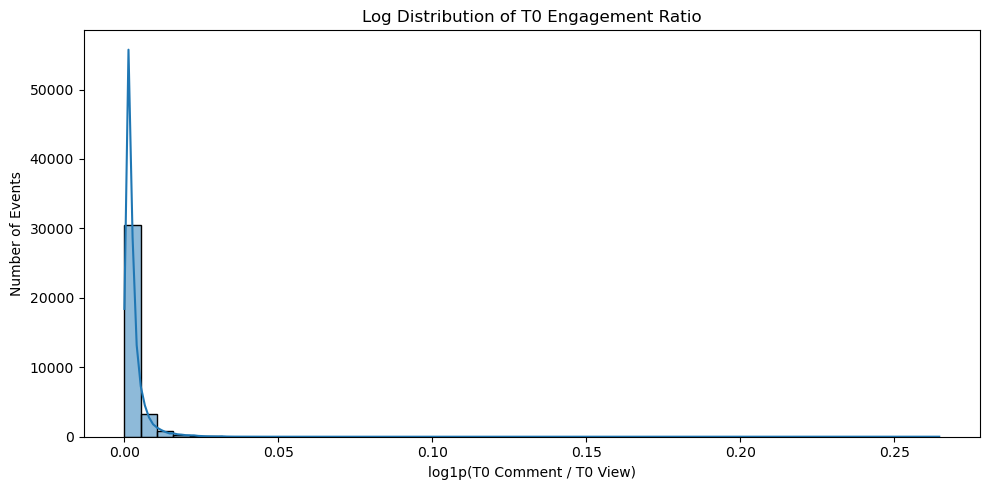

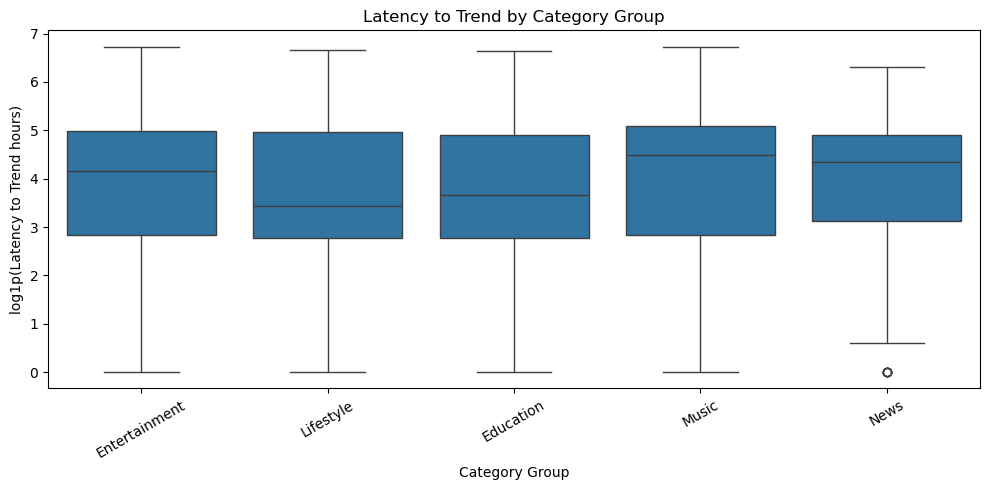

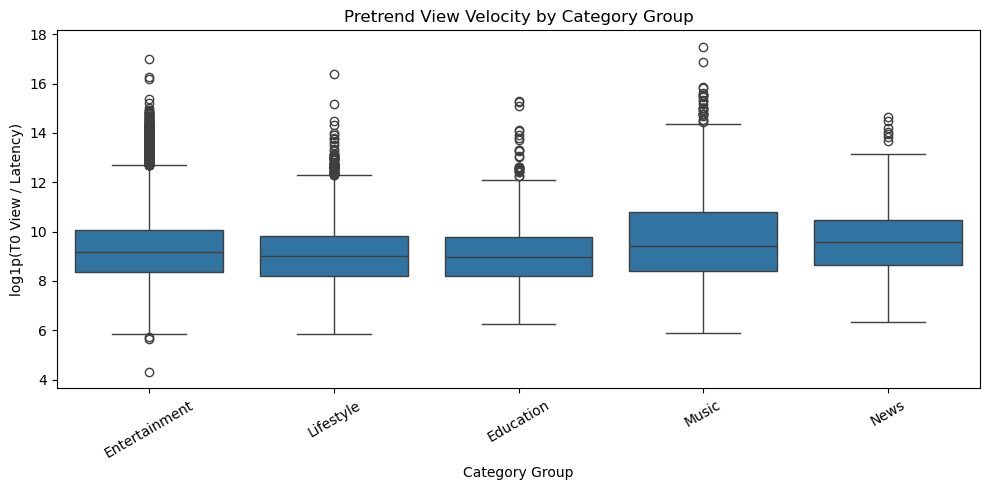

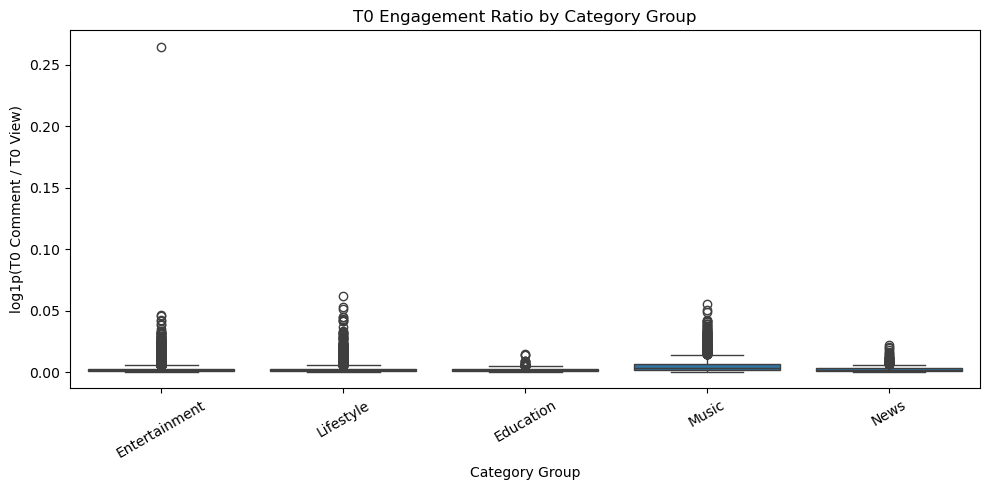

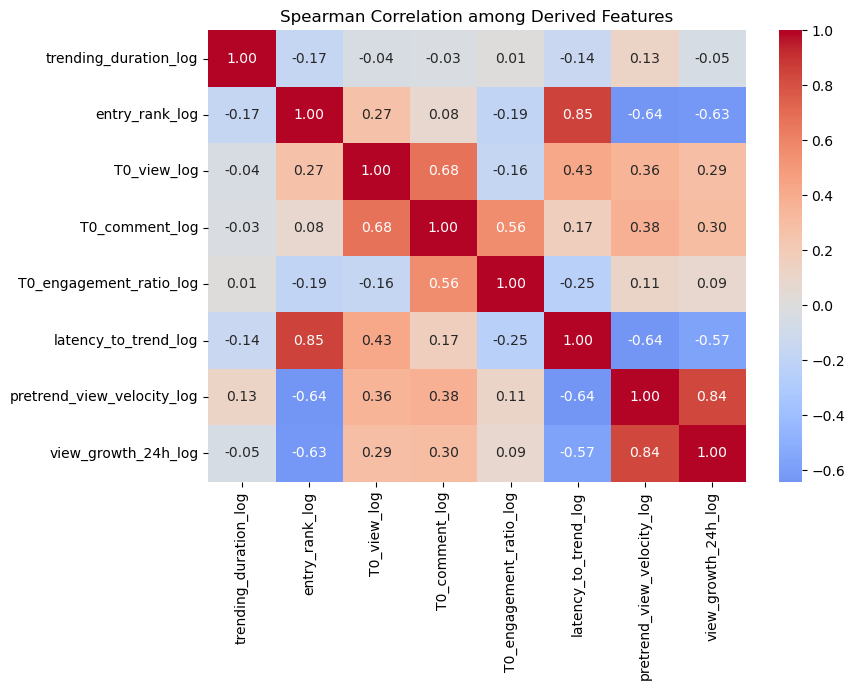

In [113]:
# =========================
# Step 6 EDA 시각화
# =========================

import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. latency_to_trend 분포
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.histplot(events['latency_to_trend_log'], bins=50, kde=True)
plt.title('Log Distribution of Latency to Trend')
plt.xlabel('log1p(Latency to Trend hours)')
plt.ylabel('Number of Events')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2. pretrend_view_velocity 분포
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.histplot(events['pretrend_view_velocity_log'], bins=50, kde=True)
plt.title('Log Distribution of Pretrend View Velocity')
plt.xlabel('log1p(T0 View / Latency to Trend)')
plt.ylabel('Number of Events')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. T0 engagement ratio 분포
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.histplot(events['T0_engagement_ratio_log'].dropna(), bins=50, kde=True)
plt.title('Log Distribution of T0 Engagement Ratio')
plt.xlabel('log1p(T0 Comment / T0 View)')
plt.ylabel('Number of Events')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. 카테고리별 latency_to_trend
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=events,
    x='category_group',
    y='latency_to_trend_log'
)
plt.title('Latency to Trend by Category Group')
plt.xlabel('Category Group')
plt.ylabel('log1p(Latency to Trend hours)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. 카테고리별 pretrend velocity
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=events,
    x='category_group',
    y='pretrend_view_velocity_log'
)
plt.title('Pretrend View Velocity by Category Group')
plt.xlabel('Category Group')
plt.ylabel('log1p(T0 View / Latency)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 6. 카테고리별 T0 engagement ratio
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=events,
    x='category_group',
    y='T0_engagement_ratio_log'
)
plt.title('T0 Engagement Ratio by Category Group')
plt.xlabel('Category Group')
plt.ylabel('log1p(T0 Comment / T0 View)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 7. 초기 피처와 지속시간의 Spearman 상관
# ---------------------------------------------------------
corr_cols = [
    'trending_duration_log',
    'entry_rank_log',
    'T0_view_log',
    'T0_comment_log',
    'T0_engagement_ratio_log',
    'latency_to_trend_log',
    'pretrend_view_velocity_log'
]

if 'view_growth_24h_log' in events.columns:
    corr_cols.append('view_growth_24h_log')

corr_df = events[corr_cols].corr(method='spearman')

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_df,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title('Spearman Correlation among Derived Features')
plt.tight_layout()
plt.show()

In [114]:
# =========================
# Step 7. 타겟 변수 생성: 지속 시간 label + TDI 보조 지표
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

events = events.copy()

# ---------------------------------------------------------
# 1. 지속 시간 기준 label 생성
# ---------------------------------------------------------

# 전체 기준 상위 25%를 장기 지속 이벤트로 정의
global_q75_duration = events['trending_duration_h'].quantile(0.75)

events['long_label_global_q75'] = (
    events['trending_duration_h'] >= global_q75_duration
).astype(int)

print("[전체 기준 q75 지속 시간]")
print(global_q75_duration)

print("\n[long_label_global_q75 분포]")
print(events['long_label_global_q75'].value_counts(dropna=False))
print(events['long_label_global_q75'].value_counts(normalize=True, dropna=False).round(4))


# 카테고리 내부 기준 상위 25%를 장기 지속 이벤트로 정의
cat_q75_duration = (
    events.groupby('category_group')['trending_duration_h']
    .transform(lambda x: x.quantile(0.75))
)

events['cat_q75_duration'] = cat_q75_duration

events['long_label_cat_q75'] = (
    events['trending_duration_h'] >= events['cat_q75_duration']
).astype(int)

print("\n[카테고리별 q75 지속 시간]")
display(
    events.groupby('category_group')['cat_q75_duration']
    .first()
    .sort_values(ascending=False)
)

print("\n[long_label_cat_q75 분포]")
print(events['long_label_cat_q75'].value_counts(dropna=False))
print(events['long_label_cat_q75'].value_counts(normalize=True, dropna=False).round(4))


# ---------------------------------------------------------
# 2. 고정 시간 기준 label 후보
# ---------------------------------------------------------

print("\n[고정 threshold별 장기 지속 비율]")
for h in [24, 48, 72, 96, 120, 168]:
    ratio = (events['trending_duration_h'] >= h).mean()
    print(f"{h:>3}h 이상 지속: {ratio:.2%}")

events['long_label_48h'] = (
    events['trending_duration_h'] >= 48
).astype(int)

print("\n[long_label_48h 분포]")
print(events['long_label_48h'].value_counts(dropna=False))
print(events['long_label_48h'].value_counts(normalize=True, dropna=False).round(4))


# ---------------------------------------------------------
# 3. TDI 산출
# ---------------------------------------------------------
# TDI = 카테고리 내 상대 지속 시간 × 최고 순위 성과
# 주의: TDI는 사후 성과 지표이며 예측 피처로 사용 금지

cat_q95 = (
    events.groupby('category_group')['trending_duration_h']
    .quantile(0.95)
)

events['cat_q95_duration'] = events['category_group'].map(cat_q95)

events['duration_score_cat'] = (
    events['trending_duration_h'] / events['cat_q95_duration']
).clip(0, 1)

# best_rank는 낮을수록 좋은 순위
# best_rank=1이면 1점, best_rank=200이면 0.005점
events['rank_score'] = (
    1 - (events['best_rank'] - 1) / 200
).clip(0, 1)

events['TDI'] = (
    events['duration_score_cat'] * events['rank_score']
).clip(0, 1)

print("\n[TDI 요약]")
print(events['TDI'].describe())


# ---------------------------------------------------------
# 4. TDI threshold별 분포 및 지속 시간 차이 확인
# ---------------------------------------------------------

tdi_thresholds = [0.3, 0.4, 0.5]

print("\n[TDI threshold별 positive 비율 및 지속 시간 요약]")

tdi_threshold_summary = []

for th in tdi_thresholds:
    temp_label = (events['TDI'] >= th).astype(int)

    pos_ratio = temp_label.mean()
    n_pos = temp_label.sum()
    n_total = len(temp_label)

    print(f"\n=== TDI threshold {th} ===")
    print(f"positive count: {n_pos:,} / {n_total:,}")
    print(f"positive ratio: {pos_ratio:.2%}")
    print("\n[tdi_label 기준 trending_duration_h 요약]")
    print(events.groupby(temp_label)['trending_duration_h'].describe())

    tdi_threshold_summary.append({
        'threshold': th,
        'n_total': n_total,
        'n_positive': int(n_pos),
        'positive_ratio': pos_ratio,
        'negative_ratio': 1 - pos_ratio
    })

tdi_threshold_summary = pd.DataFrame(tdi_threshold_summary)

print("\n[TDI threshold 요약표]")
display(tdi_threshold_summary)


# ---------------------------------------------------------
# 5. 대표 TDI label 생성
# ---------------------------------------------------------
# 팀 확정 기준. 현재는 0.4를 대표 threshold로 사용
# 단, tdi_label은 RQ3 메인 타겟이 아니라 TDI 기반 보조 타겟으로 권장

TDI_THRESHOLD = 0.4

events['tdi_label'] = (
    events['TDI'] >= TDI_THRESHOLD
).astype(int)

print(f"\n[대표 tdi_label 분포: threshold={TDI_THRESHOLD}]")
print(events['tdi_label'].value_counts(dropna=False))
print(events['tdi_label'].value_counts(normalize=True, dropna=False).round(4))


# ---------------------------------------------------------
# 6. 타겟 후보 정리
# ---------------------------------------------------------

target_regression = 'trending_duration_h'
target_regression_log = 'trending_duration_log'

target_classification_main = 'long_label_global_q75'
target_classification_cat = 'long_label_cat_q75'
target_classification_fixed = 'long_label_48h'
target_classification_tdi = 'tdi_label'

print("\n[타겟 후보]")
print("회귀 타겟:", target_regression)
print("로그 회귀 타겟:", target_regression_log)
print("분류 메인 타겟:", target_classification_main)
print("카테고리 보정 분류 타겟:", target_classification_cat)
print("고정 기준 분류 타겟:", target_classification_fixed)
print("보조 TDI 분류 타겟:", target_classification_tdi)

[전체 기준 q75 지속 시간]
240.0

[long_label_global_q75 분포]
long_label_global_q75
0    26105
1     8859
Name: count, dtype: int64
long_label_global_q75
0    0.7466
1    0.2534
Name: proportion, dtype: float64

[카테고리별 q75 지속 시간]


category_group
Lifestyle        300.0
Education        288.0
Entertainment    222.0
Music            198.0
News             180.0
Name: cat_q75_duration, dtype: float64


[long_label_cat_q75 분포]
long_label_cat_q75
0    26127
1     8837
Name: count, dtype: int64
long_label_cat_q75
0    0.7473
1    0.2527
Name: proportion, dtype: float64

[고정 threshold별 장기 지속 비율]
 24h 이상 지속: 77.89%
 48h 이상 지속: 67.27%
 72h 이상 지속: 58.58%
 96h 이상 지속: 52.47%
120h 이상 지속: 48.33%
168h 이상 지속: 40.91%

[long_label_48h 분포]
long_label_48h
1    23522
0    11442
Name: count, dtype: int64
long_label_48h
1    0.6727
0    0.3273
Name: proportion, dtype: float64

[TDI 요약]
count    34964.000000
mean         0.312568
std          0.280660
min          0.000071
25%          0.059667
50%          0.246250
75%          0.503571
max          1.000000
Name: TDI, dtype: float64

[TDI threshold별 positive 비율 및 지속 시간 요약]

=== TDI threshold 0.3 ===
positive count: 15,614 / 34,964
positive ratio: 44.66%

[tdi_label 기준 trending_duration_h 요약]
       count        mean        std   min    25%    50%    75%    max
TDI                                                                  
0    19350.0   46.4040

,threshold,n_total,n_positive,positive_ratio,negative_ratio
0,0.3,34964,15614,0.446574,0.553426
1,0.4,34964,12062,0.344983,0.655017
2,0.5,34964,8851,0.253146,0.746854



[대표 tdi_label 분포: threshold=0.4]
tdi_label
0    22902
1    12062
Name: count, dtype: int64
tdi_label
0    0.655
1    0.345
Name: proportion, dtype: float64

[타겟 후보]
회귀 타겟: trending_duration_h
로그 회귀 타겟: trending_duration_log
분류 메인 타겟: long_label_global_q75
카테고리 보정 분류 타겟: long_label_cat_q75
고정 기준 분류 타겟: long_label_48h
보조 TDI 분류 타겟: tdi_label


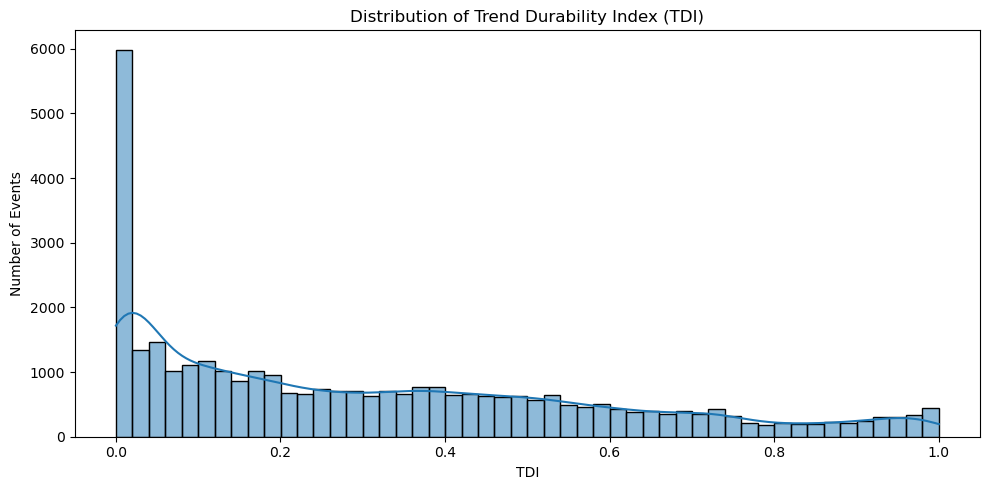

In [115]:
# TDI 분포
plt.figure(figsize=(10, 5))
sns.histplot(events['TDI'], bins=50, kde=True)
plt.title('Distribution of Trend Durability Index (TDI)')
plt.xlabel('TDI')
plt.ylabel('Number of Events')
plt.tight_layout()
plt.show()

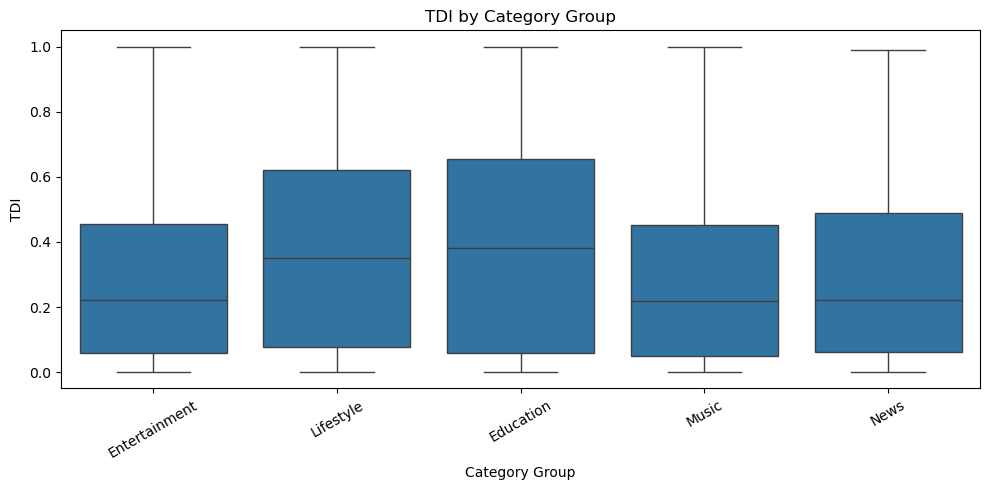

In [116]:
# 카테고리별 TDI 분포
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=events,
    x='category_group',
    y='TDI'
)
plt.title('TDI by Category Group')
plt.xlabel('Category Group')
plt.ylabel('TDI')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

,class_0,class_1
long_label_global_q75,0.746625,0.253375
long_label_cat_q75,0.747254,0.252746
long_label_48h,0.327251,0.672749
tdi_label_04,0.655017,0.344983


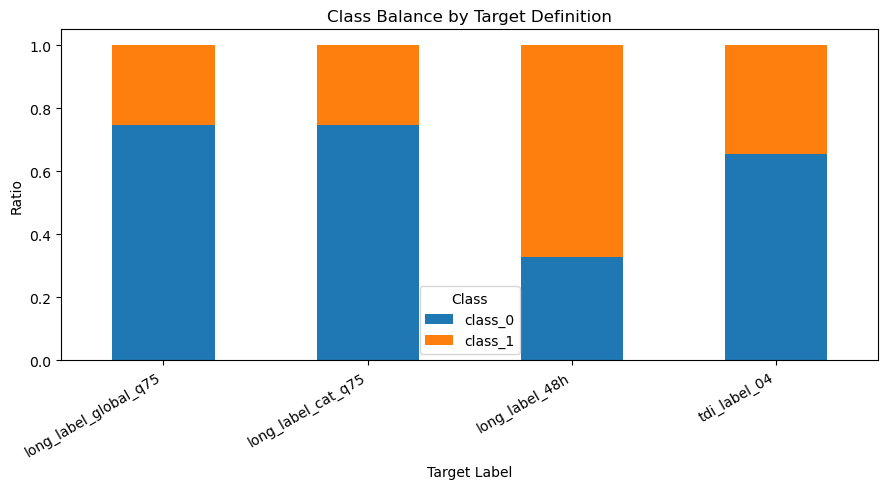

In [117]:
# 지속 시간 label 분포 비교
label_summary = pd.DataFrame({
    'long_label_global_q75': events['long_label_global_q75'].value_counts(normalize=True),
    'long_label_cat_q75': events['long_label_cat_q75'].value_counts(normalize=True),
    'long_label_48h': events['long_label_48h'].value_counts(normalize=True),
    'tdi_label_04': events['tdi_label'].value_counts(normalize=True)
}).T

label_summary.columns = ['class_0', 'class_1']
display(label_summary)

label_summary[['class_0', 'class_1']].plot(
    kind='bar',
    stacked=True,
    figsize=(9, 5)
)

plt.title('Class Balance by Target Definition')
plt.xlabel('Target Label')
plt.ylabel('Ratio')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Class')
plt.tight_layout()
plt.show()

,n_events,n_long,long_ratio
category_group,,,
Lifestyle,8497,3456,0.406732
Education,593,225,0.379427
Entertainment,19646,4257,0.216685
Music,5241,836,0.159512
News,987,85,0.086120


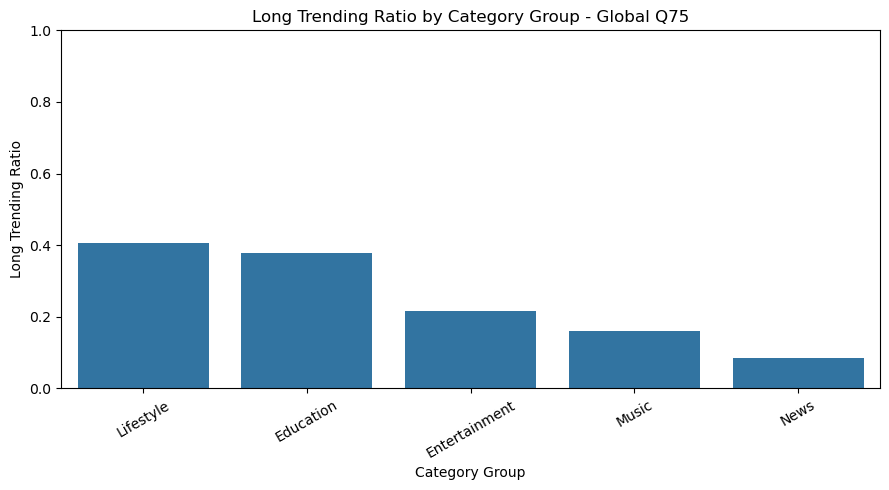

In [118]:
# 카테고리별 장기 지속 비율
cat_long_ratio = (
    events.groupby('category_group')['long_label_global_q75']
    .agg(['count', 'sum', 'mean'])
    .rename(columns={
        'count': 'n_events',
        'sum': 'n_long',
        'mean': 'long_ratio'
    })
    .sort_values('long_ratio', ascending=False)
)

display(cat_long_ratio)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=cat_long_ratio.reset_index(),
    x='category_group',
    y='long_ratio'
)
plt.title('Long Trending Ratio by Category Group - Global Q75')
plt.xlabel('Category Group')
plt.ylabel('Long Trending Ratio')
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

,n_events,n_long,long_ratio
category_group,,,
Lifestyle,8497,2168,0.255149
Education,593,151,0.254637
Music,5241,1329,0.253578
Entertainment,19646,4941,0.251502
News,987,248,0.251266


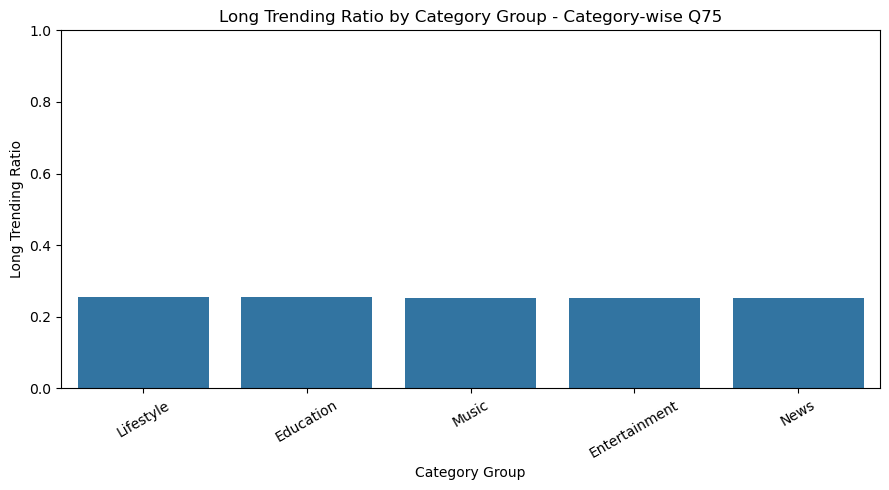

In [119]:
# 카테고리 보정 label의 카테고리별 비율 확인
# long_label_cat_q75는 카테고리별 상위 25%를 1로 만드는 방식이라, 각 카테고리 안에서 positive 비율이 비슷
cat_long_ratio_cat = (
    events.groupby('category_group')['long_label_cat_q75']
    .agg(['count', 'sum', 'mean'])
    .rename(columns={
        'count': 'n_events',
        'sum': 'n_long',
        'mean': 'long_ratio'
    })
    .sort_values('long_ratio', ascending=False)
)

display(cat_long_ratio_cat)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=cat_long_ratio_cat.reset_index(),
    x='category_group',
    y='long_ratio'
)
plt.title('Long Trending Ratio by Category Group - Category-wise Q75')
plt.xlabel('Category Group')
plt.ylabel('Long Trending Ratio')
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

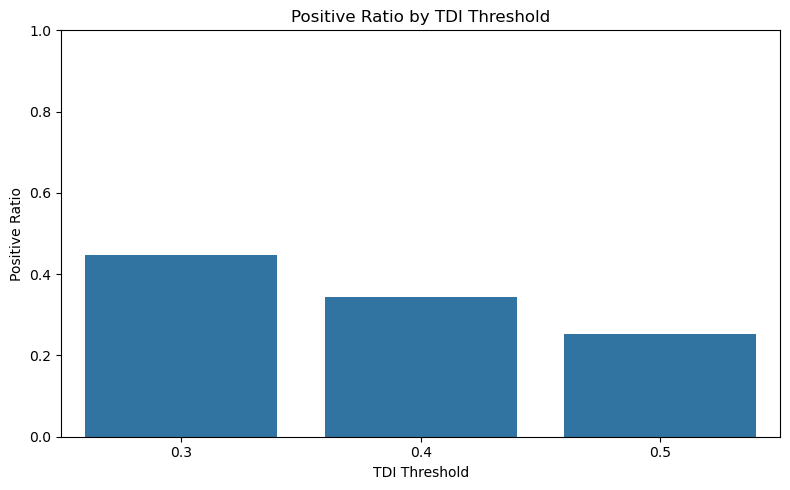

In [120]:
# TDI 임계값별 positive 비율
plt.figure(figsize=(8, 5))

sns.barplot(
    data=tdi_threshold_summary,
    x='threshold',
    y='positive_ratio'
)

plt.title('Positive Ratio by TDI Threshold')
plt.xlabel('TDI Threshold')
plt.ylabel('Positive Ratio')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

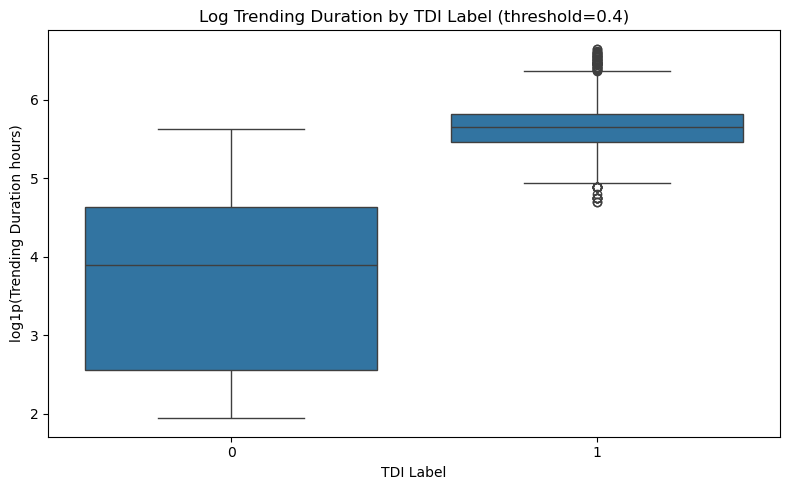

In [121]:
# TDI label별 지속 시간 차이
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=events,
    x='tdi_label',
    y='trending_duration_log'
)

plt.title(f'Log Trending Duration by TDI Label (threshold={TDI_THRESHOLD})')
plt.xlabel('TDI Label')
plt.ylabel('log1p(Trending Duration hours)')
plt.tight_layout()
plt.show()

,n_events,n_tdi_positive,tdi_positive_ratio
category_group,,,
Education,593,287,0.483980
Lifestyle,8497,3888,0.457573
News,987,335,0.339412
Music,5241,1610,0.307193
Entertainment,19646,5942,0.302453


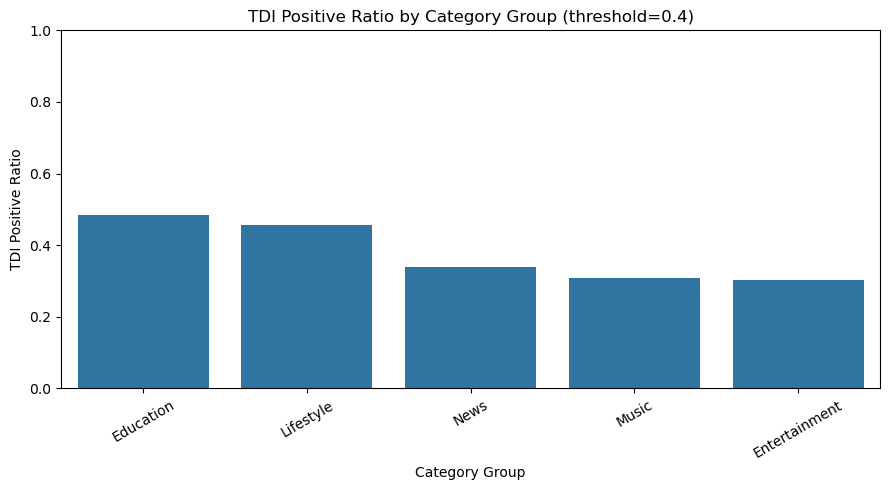

In [122]:
# 카테고리별 TDI positive 비율
tdi_ratio_by_cat = (
    events.groupby('category_group')['tdi_label']
    .agg(['count', 'sum', 'mean'])
    .rename(columns={
        'count': 'n_events',
        'sum': 'n_tdi_positive',
        'mean': 'tdi_positive_ratio'
    })
    .sort_values('tdi_positive_ratio', ascending=False)
)

display(tdi_ratio_by_cat)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=tdi_ratio_by_cat.reset_index(),
    x='category_group',
    y='tdi_positive_ratio'
)

plt.title(f'TDI Positive Ratio by Category Group (threshold={TDI_THRESHOLD})')
plt.xlabel('Category Group')
plt.ylabel('TDI Positive Ratio')
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [123]:
# =========================
# Step 8. Saturation Index 계산 + EDA
# =========================

# 목적:
# - 특정 시점에 같은 카테고리의 트렌딩 진입이 얼마나 많은지 나타내는
#   카테고리별 혼잡도/포화도 변수를 생성
#
# 주의:
# - saturation_index_same_day_eda:
#   같은 날짜 전체 이벤트 수를 쓰므로 당일 미래 정보가 섞일 수 있음
#   → EDA용, 예측 피처 사용 금지
#
# - saturation_index_prev:
#   전날 하루 이벤트 수 / 전날까지 최근 30일 최대 이벤트 수
#   → 예측용으로 사용 가능하지만 일별 변동성이 큼
#
# - saturation_index_30d_mean_prev:
#   전날까지 최근 30일 평균 이벤트 수 / 전날까지 최근 30일 최대 이벤트 수
#   → 더 안정적인 예측용 포화도 변수

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

events = events.copy()

# ---------------------------------------------------------
# 0. 재실행 대비: 기존 saturation 관련 컬럼 제거
# ---------------------------------------------------------
sat_cols_to_drop = [
    'T0_date',
    'same_day_category_event_count',
    'saturation_index_prev',
    'saturation_index_same_day_eda',
    'saturation_index_30d_mean_prev',
    'rolling_30d_mean_prev'
]

events = events.drop(
    columns=[c for c in sat_cols_to_drop if c in events.columns],
    errors='ignore'
)

# ---------------------------------------------------------
# 1. 날짜 변수 생성
# ---------------------------------------------------------
# dt.date보다 datetime64 형태가 이후 rolling/merge에 더 안전함
events['T0_date'] = events['T0'].dt.normalize()

# ---------------------------------------------------------
# 2. 일자-카테고리별 이벤트 수 계산
# ---------------------------------------------------------
# video_id 기준이 아니라 event 단위 기준으로 계산
daily_cat = (
    events.groupby(['T0_date', 'category_group'])
    .size()
    .reset_index(name='event_count')
)

# ---------------------------------------------------------
# 3. 모든 날짜 × 카테고리 조합 생성
# ---------------------------------------------------------
# 특정 날짜에 해당 카테고리 이벤트가 0개인 경우도 rolling 계산에 반영하기 위함
all_dates = pd.date_range(
    start=events['T0_date'].min(),
    end=events['T0_date'].max(),
    freq='D'
)

all_categories = sorted(events['category_group'].dropna().unique())

full_index = pd.MultiIndex.from_product(
    [all_dates, all_categories],
    names=['T0_date', 'category_group']
)

daily_cat_full = (
    daily_cat.set_index(['T0_date', 'category_group'])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

daily_cat_full = daily_cat_full.sort_values(['category_group', 'T0_date'])

# ---------------------------------------------------------
# 4. EDA용 same-day saturation index
# ---------------------------------------------------------
# 당일 전체 이벤트 수를 사용하므로 예측 피처로 사용하지 않음
daily_cat_full['rolling_30d_max_including_today'] = (
    daily_cat_full
    .groupby('category_group')['event_count']
    .transform(lambda x: x.rolling(30, min_periods=1).max())
)

daily_cat_full['saturation_index_same_day_eda'] = (
    daily_cat_full['event_count'] /
    daily_cat_full['rolling_30d_max_including_today'].replace(0, np.nan)
).clip(0, 1).fillna(0)

# ---------------------------------------------------------
# 5. 예측용 saturation index: 전날까지의 정보만 사용
# ---------------------------------------------------------

# 전날 해당 카테고리 이벤트 수
daily_cat_full['prev_event_count'] = (
    daily_cat_full
    .groupby('category_group')['event_count']
    .shift(1)
)

# 전날까지 최근 30일 최대 이벤트 수
daily_cat_full['rolling_30d_max_prev'] = (
    daily_cat_full
    .groupby('category_group')['event_count']
    .transform(lambda x: x.shift(1).rolling(30, min_periods=1).max())
)

# 전날까지 최근 30일 평균 이벤트 수
daily_cat_full['rolling_30d_mean_prev'] = (
    daily_cat_full
    .groupby('category_group')['event_count']
    .transform(lambda x: x.shift(1).rolling(30, min_periods=1).mean())
)

# 어제 기준 단기 포화도
daily_cat_full['saturation_index_prev'] = (
    daily_cat_full['prev_event_count'] /
    daily_cat_full['rolling_30d_max_prev'].replace(0, np.nan)
).clip(0, 1).fillna(0)

# 최근 30일 평균 기준 안정형 포화도
daily_cat_full['saturation_index_30d_mean_prev'] = (
    daily_cat_full['rolling_30d_mean_prev'] /
    daily_cat_full['rolling_30d_max_prev'].replace(0, np.nan)
).clip(0, 1).fillna(0)

# ---------------------------------------------------------
# 6. events에 병합
# ---------------------------------------------------------
events = events.merge(
    daily_cat_full[
        [
            'T0_date',
            'category_group',
            'event_count',
            'saturation_index_same_day_eda',
            'saturation_index_prev',
            'saturation_index_30d_mean_prev',
            'rolling_30d_mean_prev'
        ]
    ],
    on=['T0_date', 'category_group'],
    how='left'
)

events = events.rename(columns={
    'event_count': 'same_day_category_event_count'
})

# ---------------------------------------------------------
# 7. 결과 확인
# ---------------------------------------------------------
print("[saturation_index_prev 요약: 예측용, 전날 기준]")
print(events['saturation_index_prev'].describe())

print("\n[saturation_index_30d_mean_prev 요약: 예측용, 30일 평균 기준]")
print(events['saturation_index_30d_mean_prev'].describe())

print("\n[saturation_index_same_day_eda 요약: EDA용]")
print(events['saturation_index_same_day_eda'].describe())

print("\n[결측치 확인]")
print(events[
    [
        'same_day_category_event_count',
        'saturation_index_prev',
        'saturation_index_30d_mean_prev',
        'saturation_index_same_day_eda',
        'rolling_30d_mean_prev'
    ]
].isnull().sum())

print("\n[카테고리별 saturation_index_prev 평균]")
display(
    events.groupby('category_group')['saturation_index_prev']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .sort_values('mean', ascending=False)
)

print("\n[카테고리별 saturation_index_30d_mean_prev 평균]")
display(
    events.groupby('category_group')['saturation_index_30d_mean_prev']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .sort_values('mean', ascending=False)
)

[saturation_index_prev 요약: 예측용, 전날 기준]
count    34964.000000
mean         0.426455
std          0.264903
min          0.000000
25%          0.200000
50%          0.413793
75%          0.600000
max          1.000000
Name: saturation_index_prev, dtype: float64

[saturation_index_30d_mean_prev 요약: 예측용, 30일 평균 기준]
count    34964.000000
mean         0.424426
std          0.162970
min          0.000000
25%          0.300000
50%          0.479012
75%          0.548039
max          1.000000
Name: saturation_index_30d_mean_prev, dtype: float64

[saturation_index_same_day_eda 요약: EDA용]
count    34964.000000
mean         0.535924
std          0.283144
min          0.007874
25%          0.295120
50%          0.529412
75%          0.750000
max          1.000000
Name: saturation_index_same_day_eda, dtype: float64

[결측치 확인]
same_day_category_event_count       0
saturation_index_prev               0
saturation_index_30d_mean_prev      0
saturation_index_same_day_eda       0
rolling_30d_mean_prev      

,count,mean,median,std,min,max
category_group,,,,,,
Entertainment,19646,0.450474,0.451613,0.255361,0.0,1.0
Lifestyle,8497,0.414008,0.400000,0.264301,0.0,1.0
Music,5241,0.396523,0.363636,0.260178,0.0,1.0
News,987,0.319991,0.250000,0.335916,0.0,1.0
Education,593,0.250821,0.000000,0.334313,0.0,1.0



[카테고리별 saturation_index_30d_mean_prev 평균]


,count,mean,median,std,min,max
category_group,,,,,,
Entertainment,19646,0.455426,0.517241,0.164558,0.0,1.0
Lifestyle,8497,0.410417,0.461111,0.162556,0.0,1.0
Music,5241,0.383710,0.406061,0.123564,0.0,1.0
News,987,0.279010,0.300000,0.096775,0.0,0.5
Education,593,0.199993,0.200000,0.069913,0.0,0.5


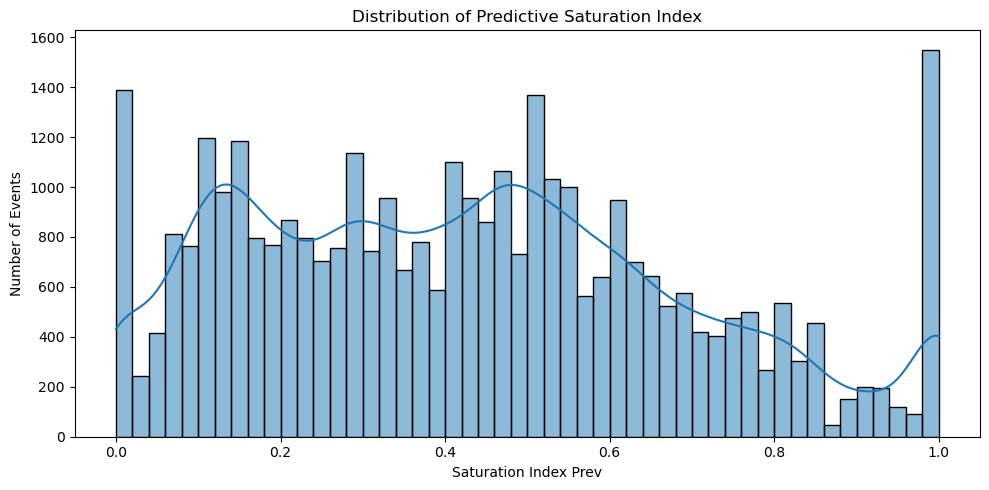

In [124]:
# 예측용 saturation index 분포
plt.figure(figsize=(10, 5))

sns.histplot(
    events['saturation_index_prev'],
    bins=50,
    kde=True
)

plt.title('Distribution of Predictive Saturation Index')
plt.xlabel('Saturation Index Prev')
plt.ylabel('Number of Events')
plt.tight_layout()
plt.show()

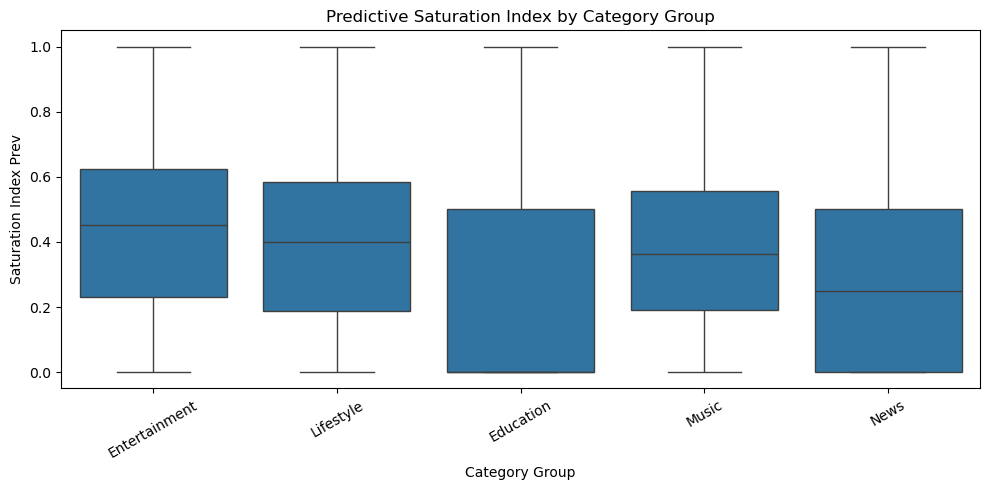

In [125]:
# 카테고리별 saturation index
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=events,
    x='category_group',
    y='saturation_index_prev'
)

plt.title('Predictive Saturation Index by Category Group')
plt.xlabel('Category Group')
plt.ylabel('Saturation Index Prev')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


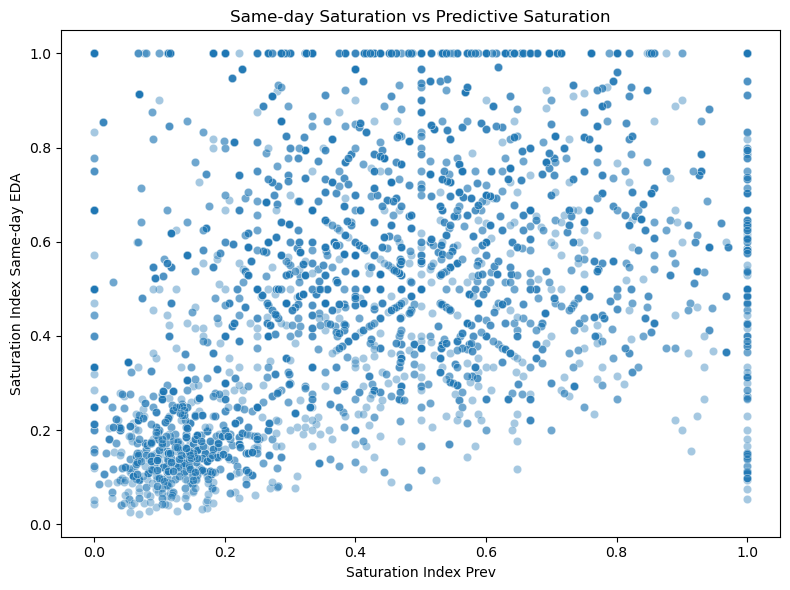

In [126]:
# 같은 날짜 기준 EDA용 포화도와 예측용 포화도 비교
# 점들이 대각선 근처에 많으면 전날 포화도와 당일 포화도가 비슷한 편
# 흩어져 있으면 당일 이벤트 수 변동이 크다는 의미
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=events.sample(min(5000, len(events)), random_state=42),
    x='saturation_index_prev',
    y='saturation_index_same_day_eda',
    alpha=0.4
)

plt.title('Same-day Saturation vs Predictive Saturation')
plt.xlabel('Saturation Index Prev')
plt.ylabel('Saturation Index Same-day EDA')
plt.tight_layout()
plt.show()

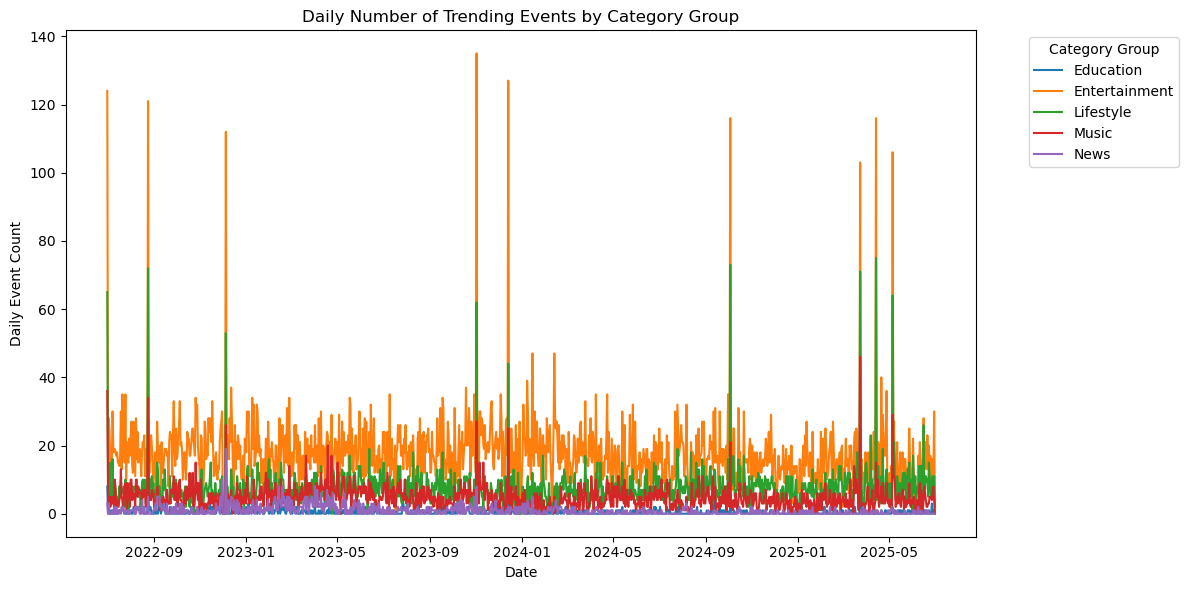

In [127]:
# 날짜별 카테고리 이벤트 수 추이
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=daily_cat_full,
    x='T0_date',
    y='event_count',
    hue='category_group'
)

plt.title('Daily Number of Trending Events by Category Group')
plt.xlabel('Date')
plt.ylabel('Daily Event Count')
plt.legend(title='Category Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [128]:
features_T0 = [
    'category_group',
    'entry_rank_log',
    'T0_view_log',
    'T0_comment_log',
    'T0_engagement_ratio_log',
    'latency_to_trend_log',
    'pretrend_view_velocity_log',
    'published_weekday',
    'hour_sin',
    'hour_cos',
    'saturation_index_prev'
]

features_24h = [
    'category_group',
    'entry_rank_log',
    'T0_view_log',
    'T0_comment_log',
    'T0_engagement_ratio_log',
    'latency_to_trend_log',
    'pretrend_view_velocity_log',
    'published_weekday',
    'hour_sin',
    'hour_cos',
    'saturation_index_prev',
    'view_growth_24h_log'
]

In [129]:
forbidden_features += [
    'saturation_index_same_day_eda',
    'same_day_category_event_count'
]

In [ ]:
# =========================
# Step 9. 최종 데이터 저장
# =========================

# 목적:
# - 분석용 events 테이블과 모델링용 테이블을 분리 저장
# - T0 모델과 24h 모델을 분리하여 데이터 누수 방지
# - snapshot 원본과 saturation 계산 테이블도 함께 저장

import os
import pandas as pd
import numpy as np

# 저장 폴더
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------------------------------------------------------
# 1. 분석용 이벤트 테이블 컬럼
# ---------------------------------------------------------
# 분석용 테이블은 사후 변수 포함 가능
# 단, 모델링 시에는 이 테이블을 그대로 X로 사용하지 않도록 주의

analysis_cols = [
    # key
    'video_id', 'event_id',
    'channel_id', 'channel_title', 'title',

    # time
    'T0', 'T_end', 'published_at', 'T0_date',
    'n_snapshots', 'is_single_snapshot',

    # category
    'category_id', 'category_group',

    # target / labels
    'trending_duration_h',
    'trending_duration_log',
    'trending_duration_h_raw',
    'long_label_global_q75',
    'long_label_cat_q75',
    'long_label_48h',

    # TDI target / score
    'cat_q75_duration',
    'cat_q95_duration',
    'duration_score_cat',
    'rank_score',
    'TDI',
    'tdi_label',

    # T0 features
    'entry_rank',
    'entry_rank_log',
    'T0_view',
    'T0_view_log',
    'T0_comment',
    'T0_comment_log',
    'T0_engagement_ratio',
    'T0_engagement_ratio_log',
    'latency_to_trend_h',
    'latency_to_trend_log',
    'pretrend_view_velocity',
    'pretrend_view_velocity_log',
    'published_weekday',
    'published_hour',
    'hour_sin',
    'hour_cos',

    # optional metadata / check
    'has_korean_title',

    # 24h features
    'has_24h_observation',
    'has_exact_24h_snapshot',
    'actual_time_at_24h',
    'actual_gap_to_24h',
    'view_at_24h',
    'view_growth_24h',
    'view_growth_24h_log',

    # saturation
    'saturation_index_prev',
    'saturation_index_same_day_eda',
    'same_day_category_event_count',
    'rolling_30d_mean_prev',

    # post-event analysis only
    'best_rank',
    'peak_view',
    'T_end_view',
    'T_end_comment',
    'observed_view_velocity',
    'observed_comment_growth',

    # EDA winsorized variables
    'trending_duration_h_wins_eda',
    'T0_engagement_ratio_wins_eda',
    'pretrend_view_velocity_wins_eda',
    'view_growth_24h_wins_eda'
]

analysis_cols = [c for c in analysis_cols if c in events.columns]

missing_analysis = [c for c in analysis_cols if c not in events.columns]
print("[analysis_cols 누락 컬럼]")
print(missing_analysis)

video_trending_events_analysis = events[analysis_cols].copy()

# ---------------------------------------------------------
# 2. T0 모델용 테이블
# ---------------------------------------------------------
# 전체 이벤트 사용
# 트렌딩 진입 시점에 알 수 있는 변수만 포함
# view_growth_24h, has_24h_observation, best_rank, T_end_view 등 제외

target_cols = [
    'trending_duration_h',
    'trending_duration_log',
    'long_label_global_q75',
    'long_label_cat_q75',
    'long_label_48h',
    'tdi_label'
]

id_cols = [
    'video_id', 'event_id',
    'channel_id', 'channel_title', 'title',
    'T0', 'published_at',
    'category_id'
]

features_T0 = [
    'category_group',
    'entry_rank_log',
    'T0_view_log',
    'T0_comment_log',
    'T0_engagement_ratio_log',
    'latency_to_trend_log',
    'pretrend_view_velocity_log',
    'published_weekday',
    'hour_sin',
    'hour_cos',
    'saturation_index_30d_mean_prev'
]

model_T0_cols = id_cols + target_cols + features_T0
model_T0_cols = [c for c in model_T0_cols if c in events.columns]

missing_T0 = [c for c in id_cols + target_cols + features_T0 if c not in events.columns]
print("\n[T0 모델용 누락 컬럼]")
print(missing_T0)

video_trending_events_T0_model = events[model_T0_cols].copy()

# ---------------------------------------------------------
# 3. 24h 모델용 테이블
# ---------------------------------------------------------
# 24시간 이상 관측된 이벤트만 사용
# view_growth_24h_log 사용 가능
# has_24h_observation은 필터 조건으로만 쓰고 피처에는 포함하지 않음

if 'has_24h_observation' in events.columns:
    events_24h = events[events['has_24h_observation'] == True].copy()
else:
    raise ValueError("has_24h_observation 컬럼이 없습니다. Step 4/5 병합을 확인하세요.")

features_24h = [
    'category_group',
    'entry_rank_log',
    'T0_view_log',
    'T0_comment_log',
    'T0_engagement_ratio_log',
    'latency_to_trend_log',
    'pretrend_view_velocity_log',
    'published_weekday',
    'hour_sin',
    'hour_cos',
    'saturation_index_30d_mean_prev',  # 수정
    'view_growth_24h_log'
]

model_24h_cols = id_cols + target_cols + features_24h
model_24h_cols = [c for c in model_24h_cols if c in events_24h.columns]

missing_24h = [c for c in id_cols + target_cols + features_24h if c not in events_24h.columns]
print("\n[24h 모델용 누락 컬럼]")
print(missing_24h)

video_trending_events_24h_model = events_24h[model_24h_cols].copy()


# ---------------------------------------------------------
# 4. snapshot 원본 저장
# ---------------------------------------------------------

snapshot_cols = [
    'video_id',
    'event_id',
    'collection_date',
    'rank',
    'view_count',
    'comment_count',
    'category_id',
    'category_group',
    'channel_id',
    'published_at',
    'title'
]

snapshot_cols = [c for c in snapshot_cols if c in df.columns]

trending_snapshots = df[snapshot_cols].copy()


# ---------------------------------------------------------
# 5. saturation 테이블 저장
# ---------------------------------------------------------
# Step 8에서 daily_cat_full을 만든 경우 저장
# cat_sat이 아니라 daily_cat_full이 최종 saturation 계산 테이블

if 'daily_cat_full' in globals():
    category_saturation = daily_cat_full.copy()
elif 'cat_sat' in globals():
    category_saturation = cat_sat.copy()
else:
    category_saturation = pd.DataFrame()
    print("\n[주의] daily_cat_full 또는 cat_sat 객체가 없어 category_saturation은 빈 테이블입니다.")


# ---------------------------------------------------------
# 6. 저장
# ---------------------------------------------------------

analysis_path = os.path.join(OUTPUT_DIR, 'video_trending_events_analysis.parquet')
T0_model_path = os.path.join(OUTPUT_DIR, 'video_trending_events_T0_model.parquet')
model_24h_path = os.path.join(OUTPUT_DIR, 'video_trending_events_24h_model.parquet')
snapshots_path = os.path.join(OUTPUT_DIR, 'trending_snapshots.parquet')
saturation_path = os.path.join(OUTPUT_DIR, 'category_saturation.parquet')

video_trending_events_analysis.to_parquet(analysis_path, index=False)
video_trending_events_T0_model.to_parquet(T0_model_path, index=False)
video_trending_events_24h_model.to_parquet(model_24h_path, index=False)
trending_snapshots.to_parquet(snapshots_path, index=False)

if len(category_saturation) > 0:
    category_saturation.to_parquet(saturation_path, index=False)

# ---------------------------------------------------------
# 7. 저장 결과 확인
# ---------------------------------------------------------

print("\n[저장 완료]")
print(f"analysis events      : {video_trending_events_analysis.shape} -> {analysis_path}")
print(f"T0 model events      : {video_trending_events_T0_model.shape} -> {T0_model_path}")
print(f"24h model events     : {video_trending_events_24h_model.shape} -> {model_24h_path}")
print(f"trending snapshots   : {trending_snapshots.shape} -> {snapshots_path}")
print(f"category saturation  : {category_saturation.shape} -> {saturation_path if len(category_saturation) > 0 else 'not saved'}")

print("\n[T0 모델 결측 확인]")
print(video_trending_events_T0_model.isnull().sum().sort_values(ascending=False).head(20))

print("\n[24h 모델 결측 확인]")
print(video_trending_events_24h_model.isnull().sum().sort_values(ascending=False).head(20))

print("\n[analysis 이벤트 결측 확인]")
print(video_trending_events_analysis.isnull().sum().sort_values(ascending=False).head(30))

[analysis_cols 누락 컬럼]
[]

[T0 모델용 누락 컬럼]
[]

[24h 모델용 누락 컬럼]
[]

[저장 완료]
analysis events      : (34964, 63) -> outputs\video_trending_events_analysis.parquet
T0 model events      : (34964, 25) -> outputs\video_trending_events_T0_model.parquet
24h model events     : (27234, 26) -> outputs\video_trending_events_24h_model.parquet
trending snapshots   : (872191, 11) -> outputs\trending_snapshots.parquet
category saturation  : (5485, 10) -> outputs\category_saturation.parquet

[T0 모델 결측 확인]
video_id                      0
tdi_label                     0
hour_cos                      0
hour_sin                      0
published_weekday             0
pretrend_view_velocity_log    0
latency_to_trend_log          0
T0_engagement_ratio_log       0
T0_comment_log                0
T0_view_log                   0
entry_rank_log                0
category_group                0
long_label_48h                0
event_id                      0
long_label_cat_q75            0
long_label_global_q75        